# Management Analyst: Cancellation Rate Improvement
### Created By : Ridwan & Reyner

# Section 1: Business Understanding

## Context

Hotel A, a mid-sized hospitality provider located in Portugal, has recently faced increasing challenges due to a **high booking cancellation rate**, rated at 37% in the initial dataset. This issue directly impacts both **revenue management and operational planning**. As a data analyst at Hotel A, the allocated role in this situoation is to support both the management team and the marketing team by:
- Adressing cancellation rate which impacts hotel capacity management;
- Understanding customers' consideration for cancelling that can be forwarded to marketing team for policy creation;
- Discovering patterns of cancellation that might point to some segments of interest.

## Problem Statement

High booking cancellation rates present a serious challenge to hotel operations. Each time a cancellation occurs, a room that could otherwise be sold remains empty, resulting in lost revenue and reduced operational efficiency. In an industry highly dependent on capacity planning, this uncertainty is extremely harmful. Therefore, the hotels require a system that can predict which reservations are at high risk of being canceled.

Let's assume, as according to the dataset, a 37% cancellation rate with a mean ADR of USD 100 and mean staying of 2 nights. That means with every booking, the hotel risks losing USD 74, not counting operational loss and additional costs such as empty rooms. If it were to be rounded to USD 80 per booking with an average of a full booked 100 rooms per weekend, then every weekend the hotel would lose around USD 8,000.

*Nature of the Problem:*
- Many customers cancel their bookings suddenly, sometimes even after previously canceling multiple times.
- Several booking features show patterns associated with cancellations, such as `deposit_type`, `previous_cancellations`, `lead_time`, or `market_segment`.
- There is no current data-driven system to help hotel staff anticipate potential cancellations early.

*Objectives:*
- Build a **predictive model** using machine learning to identify whether a booking (`is_canceled`) is at high risk of cancellation.
- Reduce the number of actual cancellations by providing early warnings based on model predictions.
- Provide **clear insights** for the reservation and marketing teams to inform deposit policies, booking channels, or promotional strategies.

**What happens if this is not addressed?**
- Lower occupancy rate and reduced Average Daily Rate (ADR).
- Lost revenue opportunities from other potential customers.
- Operational costs that outweigh actual revenue.

---

## Goals

Through this project, hotel management aims to gain the ability to predict whether a reservation is at high risk of cancellation. With this predictive model, the hotels can proactively design strategies, such as deposit policies or targeted customer approaches, to reduce cancellations and increase revenue.

From a technical perspective, the project aims to:
- > Develop a classification model capable of predicting `is_canceled` (0 = not canceled, 1 = canceled).
- > Achieve at least **80% F1 Score** on the test set, ensuring a balance between precision and recall so the predictions are reliable in real business settings.
- > Provide feature importance interpretation to highlight which booking attributes (e.g., `deposit_type`, `lead_time`, `adr`) have the strongest influence on cancellations.

---

## Analytical Approach

The chosen approach is to build a classification model that predicts whether a booking will be canceled or not. The steps include:

- **Identify Cancellation Patterns from Historical Data**  
  Analyze features such as `deposit_type`, `lead_time`, `adr` (average daily rate), `market_segment`, `previous_cancellations`, and `days_in_waiting_list` to uncover patterns linked to customer cancellation behavior.

- **Prepare Relevant Features**  
  Perform feature selection and engineering to strengthen the model’s ability to detect cancellation signals. For example, grouping country data (`country`), encoding categorical variables like `meal` or `distribution_channel`, and scaling numerical features.

- **Build Classification Models**  
  Apply supervised learning algorithms (e.g., Logistic Regression, Random Forest, XGBoost) to map booking features to the target label `is_canceled`.

- **Handle Class Imbalance**  
  Since about 63% of bookings are not canceled and 37% are canceled, balancing techniques such as SMOTE or class weighting will be applied.

- **Optimize Accuracy and Business Usefulness**  
  Focus on evaluation metrics such as F1 Score, Precision, and Recall to balance detection of cancellations with avoiding excessive false alarms.

This approach aims to produce not only accurate predictions but also actionable business insights for hotel strategy.

---


## Evaluation Metrics

| Actual (Row) \ Predicted (Col)         | Won't cancel the booking (0) | Will cancel the booking (1) |
|-----------------------------|--------------------------------|-------------------------------|
| **Won't cancel the booking (0)** | **True Negative (TN)**<br>Model predicts that customer won't cancel their booking, they don't cancel the booking | **False Positive (FP)**<br>Model predicts that customer will cancel their booking, while actually not cancelling |
| **Will cancel the booking (1)**   | **False Negative (FN)**<br>Model predicts that customer won't cancel their booking while actually they are cancelling | **True Positive (TP)**<br>Model predicts that customer will cancel their booking, they cancel the booking |

<br>

### Cost Simulation for Misclassification

In the context of hotel bookings, each type of misclassification brings a different business impact:

- **(FN)**  
  Model predicts *Not Canceled* but the booking is actually *Canceled*.  
  - Impact: The room remains empty, leading to a direct revenue loss.  
  - Example:  
    - Average ADR: €100  
    - Average stay: 4 nights  
    - Lost revenue = 100 × 4 = €400  
    - Additional operational cost (e.g., staffing, cleaning, utilities): ~€50  
    - **Total cost per FN ≈ €450**

- **(FP)**  
  Model predicts *Canceled* but the booking is actually *Not Canceled*.  
  - Impact: Hotel may impose unnecessary restrictions, potentially discouraging genuine guests.  
  - Example:  
    - Average ADR: €100  
    - Average stay: 4 nights  
    - If the guest cancels due to stricter policies, lost revenue = €400  
    - Assume not all guests leave, only ~50% are discouraged → expected cost ≈ €200  
    - **Total cost per FP ≈ €200**

<br>

| Error Type        | Key Business Consequences                                                       |
|-------------------|----------------------------------------------------------------------------------|
| **False Negative**| High-risk cancellation not detected → empty room, revenue loss (**450**)                 |
| **False Positive**| Valid booking wrongly flagged as canceled → poor customer experience, reputation (**200**) |

<br>

> From this simulation, **False Negatives are more expensive than False Positives**. Therefore, the model should prioritize reducing FN, even at the cost of slightly higher FP.

### Choice of Evaluation Metrics

Given the class imbalance (63% not canceled vs 37% canceled) and the different business costs of misclassification, we select metrics that capture both technical and financial performance.

- **Primary Metric: PR-AUC (Precision-Recall Area Under Curve)**  
  - More appropriate than ROC-AUC in imbalanced settings.  
  - Focuses directly on the positive class (cancellations), which is the core of our business problem.  
  - Summarizes the trade-off between precision (avoiding false alarms) and recall (catching actual cancellations).  

- **Supporting Metrics:**  
  - **Recall** → to ensure we minimize False Negatives, since each missed cancellation costs the hotel significant lost revenue.  
  - **Precision** → to control False Positives and avoid discouraging genuine customers.  
  - **F1 Score** → to provide a single balanced view of precision and recall.  
  - **Business Cost Simulation** → using the confusion matrix multiplied by estimated cost per FP (€150) and FN (€350) to evaluate the financial impact of model predictions.  

---

**Insight:**  
By making **PR-AUC the primary metric**, we align the technical evaluation with the business need: detecting cancellations effectively in an imbalanced dataset. Secondary metrics and cost simulation ensure that the chosen model not only performs well statistically but also minimizes real-world financial losses.

---

## Expected Outcomes

- Reduce potential revenue loss by anticipating cancellations before they happen.
- Provide hotel staff with early alerts on risky bookings, enabling proactive actions (e.g., deposit requests).
- Improve operational efficiency through more accurate room and resource planning.
- Support marketing teams with insights into booking behaviors (e.g., channels with higher cancellation rates).

---

## Limitations and Challenges

- **Imbalanced dataset**: Majority of bookings are not canceled, which can bias the model.
- **Geographic limitation**: Data only covers hotels in Portugal, so insights may not generalize globally.
- **Customer tracking limitation**: No customer ID, so repeat bookings by the same customer cannot be identified.
- **External factors not included**: Events like pandemics, economic downturns, or seasonal changes may affect cancellations but are not captured in the dataset.
- **Interpretability**: Model outputs need to be simplified so non-technical hotel staff can understand and use them effectively.

---
---

In [1]:
# Limit CPU usage for numerical libraries
import os
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["OMP_NUM_THREADS"] = "8"

In [2]:
# Library
import pandas as pd
import numpy as np

# # Google Colab
# from google.colab import files

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# EDA Libraries
from skrub import TableReport

# Feature Engineering
from sklearn.base import clone
from feature_engine.encoding import RareLabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score, cross_validate, LearningCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score

# Imbalance Library
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline


# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [3]:
path = "hotel_bookings.csv"
df = pd.read_csv(path)

In [4]:
display(df.head(), df.tail())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [5]:
# # General table report
# report = TableReport(df, max_plot_columns=32, max_association_columns=32)
# report

In [6]:
print("General Information:")
display(df.info())
print("")

print("5 First Rows:")
display(df.head())
print("")

print("5 Last Rows:")
display(df.tail())
print("")

print("5 Random Rows:")
display(df.sample(5))

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  


None


5 First Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



5 Last Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07



5 Random Rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
75884,City Hotel,1,351,2015,October,40,3,2,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,No Deposit,1.0,NaN,0,Transient-Party,62.00,0,0,Canceled,2015-07-06
15587,Resort Hotel,0,52,2015,July,30,20,2,5,2,1.0,0,HB,ESP,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,240.0,NaN,0,Transient,190.00,0,1,Check-Out,2015-07-27
78551,City Hotel,0,282,2015,October,41,10,2,1,2,0.0,0,BB,SWE,Offline TA/TO,TA/TO,0,0,0,A,D,0,No Deposit,21.0,NaN,0,Transient-Party,76.67,0,0,Check-Out,2015-10-13
65851,City Hotel,1,52,2017,April,15,9,2,0,2,0.0,0,SC,USA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,108.00,0,0,Canceled,2017-03-27
6947,Resort Hotel,1,90,2016,July,29,13,0,3,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,175.00,0,0,Canceled,2016-04-16


In [7]:
print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include='object'))


Numerical Summary:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Categorical Summary:


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


# Section 2: Data Understanding

The dataset contains booking records from **two types of hotels in Portugal — a Resort Hotel and a City Hotel — between July 2015 and August 2017**, totaling more than **119,000 reservations**. This dataset is compiled from multiple records of hotels in Portugal, accessed as part of the hotel association agreement. Each row represents **one reservation**, and each column provides information about booking characteristics, customer details, or operational aspects. It is important to understand identifier for companies, customers, or other privacy breach is removed or modified accordingly.

---

## 2.1 Data Source
The dataset comes from a collection of hotel booking records provided by partner hotels operating in Portugal, covering both city hotels and resort hotels.  
For privacy reasons, the actual hotel names have been anonymized, and any personally identifiable information (PII) has been removed.  

The dataset is compiled into a single CSV file (`hotel_bookings.csv`), which can be accessed directly without restrictions for analysis and modeling purposes.


## 2.2 Feature Information

The dataset consists of **32 features**, a mix of categorical and numerical variables, with the target column `is_canceled`.

| **Feature Name**              | **Data Type** | **Description**                                                                 | **Impact to Business**                                                                                                    |
|--------------------------------|---------------|---------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------|
| `hotel`                       | object        | Type of hotel (Resort Hotel or City Hotel).                                      | Compare cancellation rates between hotel types to adjust business strategies.                                              |
| `is_canceled`                 | int64         | Whether the booking was canceled (1) or not (0).                                 | Target variable for prediction; directly linked to business problem.                                                       |
| `lead_time`                   | int64         | Number of days between booking date and arrival date.                            | Long lead times are often associated with higher cancellation probability.                                                 |
| `arrival_date_year`           | int64         | Year of arrival.                                                                 | Helps analyze cancellation trends over years.                                                                              |
| `arrival_date_month`          | object        | Month of arrival (January–December).                                             | Captures seasonality in cancellations.                                                                                     |
| `arrival_date_week_number`    | int64         | Week number of the arrival date (1–52).                                          | Enables weekly trend analysis of bookings and cancellations.                                                               |
| `arrival_date_day_of_month`   | int64         | Day of the month of arrival.                                                     | Helps identify daily patterns of cancellations.                                                                            |
| `stays_in_weekend_nights`     | int64         | Number of weekend nights (Saturday/Sunday) the guest stayed or booked.           | Reveals impact of weekend demand on cancellation patterns.                                                                 |
| `stays_in_week_nights`        | int64         | Number of weeknights (Monday–Friday) the guest stayed or booked.                 | Indicates length of weekday stays; longer stays may be linked to higher cancellations.                                     |
| `adults`                      | int64         | Number of adults in the booking.                                                 | Insight into customer demographics; solo vs. family/group bookings may differ in stability.                                |
| `children`                    | float64       | Number of children in the booking.                                               | Families with children may be less likely to cancel.                                                                      |
| `babies`                      | int64         | Number of babies in the booking.                                                 | Helps identify family-oriented reservations.                                                                               |
| `meal`                        | object        | Type of meal plan booked (e.g., BB, HB, FB, SC).                                 | Detects cancellation trends by package offerings.                                                                          |
| `country`                     | object        | Country of origin of the customer.                                               | Identifies geographic markets with higher cancellation rates.                                                              |
| `market_segment`              | object        | Market segment of booking (e.g., Online TA, Offline TA, Corporate).              | Critical for targeting strategies, as some channels cancel more frequently.                                                |
| `distribution_channel`        | object        | Booking distribution channel (e.g., TA/TO, Direct).                              | Certain channels may correlate with higher cancellation likelihood.                                                        |
| `is_repeated_guest`           | int64         | Whether the guest is a returning guest (0 = No, 1 = Yes).                        | Repeat guests usually cancel less; helps build loyalty strategies.                                                         |
| `previous_cancellations`      | int64         | Number of previous cancellations by the customer.                                | Strong predictor of future cancellation risk.                                                                              |
| `previous_bookings_not_canceled` | int64      | Number of previous successful bookings not canceled.                             | Positive indicator of customer reliability.                                                                                |
| `reserved_room_type`          | object        | Room type reserved by the guest.                                                 | Identifies if certain room types are more prone to cancellations.                                                          |
| `assigned_room_type`          | object        | Room type actually assigned by the hotel.                                        | Differences between reserved and assigned types may increase cancellations.                                                |
| `booking_changes`             | int64         | Number of changes to the booking before check-in.                                | Frequent changes indicate uncertainty, raising cancellation risk.                                                          |
| `deposit_type`                | object        | Type of deposit (No Deposit, Non Refund, Refundable).                            | Strong influence: non-refundable deposits reduce cancellations.                                                            |
| `agent`                       | float64       | ID of the travel agent who made the booking.                                     | Helps monitor performance and reliability of agents.                                                                       |
| `company`                     | float64       | ID of the company making the booking.                                            | Useful for corporate accounts and their cancellation patterns.                                                             |
| `days_in_waiting_list`        | int64         | Number of days a booking was on the waiting list.                                | Longer waiting times may increase cancellation likelihood.                                                                 |
| `customer_type`               | object        | Type of customer (Transient, Contract, Group, Transient-Party).                  | Certain customer types are more stable; helps in segmentation.                                                             |
| `adr`                         | float64       | Average Daily Rate (average revenue per occupied room).                          | Direct link to revenue; cancellations of high-ADR bookings are more costly.                                                |
| `required_car_parking_spaces` | int64         | Number of car parking spaces requested.                                          | Indicator of family/business travel; more committed bookings may request parking.                                          |
| `total_of_special_requests`   | int64         | Number of special requests made by the customer.                                 | Guests with more requests are often more committed to their stay.                                                          |
| `reservation_status`          | object        | Final status of the booking (Canceled, Check-Out, No-Show).                      | Provides ground truth beyond `is_canceled`.                                                                                |
| `reservation_status_date`     | object        | Date when the booking status was set (string, can be parsed as datetime).        | Useful for analyzing timing of cancellations relative to arrival.                                                           |

---

### Relationship Between Data and Business Problem

Each feature provides potential signals for identifying cancellation risk. For example:
- Customers with `deposit_type` = *No Deposit* are much more likely to cancel compared to those with non-refundable deposits, though more thorough comparative analysis must be done later for better clarity.
- Cancellations are more common for reservations with long `lead_time`.
- Certain `market_segment` and `distribution_channel` categories (e.g., Online Travel Agencies) have higher cancellation rates.

---

### Dataset Strengths and Limitations

**Strengths:**
- Large dataset (**119,390 rows, 32 columns**) with diverse customer and booking attributes.
- Includes historical behavior (`previous_cancellations`, `is_repeated_guest`), financial metrics (`adr`), and channel data (`market_segment`, `distribution_channel`).
- Covers multiple years (2015–2017), capturing seasonality and trends.

**Limitations:**
- No unique customer ID → cannot fully track individual customer history across hotels.
- Data only covers **two types of hotels in Portugal**, which may limit global generalization.
- Certain external drivers (e.g., economic downturns, pandemics, local events) not included.
- Imbalanced target: about **63% not canceled vs. 37% canceled**, requiring rebalancing methods in model training, this is still **not fixed** as some modification along the way might change the distribution.

---
---

## 2.3 Feature Type
Here is a summary of the features available in the dataset and how they are grouped.

In [8]:
# Checking Unique Data Type
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik:", numerical_cols)

Kolom kategorikal: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']
Kolom numerik: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


### Feature Types

The dataset contains a mix of categorical and numerical features:  

- **Categorical features** such as `hotel`, `arrival_date_month`, `meal`, `country`, and `market_segment` capture booking characteristics, customer demographics, and booking channels. These variables will need to be encoded before they can be used in machine learning models.  

- **Numerical features** like `lead_time`, `stays_in_weekend_nights`, `adults`, `adr`, and `previous_cancellations` provide continuous or discrete values that can directly contribute to identifying cancellation patterns. These features often hold strong predictive signals about customer behavior.  

This balance of categorical and numerical data gives us both context (who the customer is, how they booked) and measurable patterns (how far in advance they booked, how many times they canceled before).  

---

## 2.4 Target Distribution (is_canceled)

In [9]:
# Target Distribution
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


### Target Variable Distribution

Looking at the target variable `is_canceled`:  
- About **63% of bookings were not canceled (label 0)**  
- Around **37% of bookings were canceled (label 1)**  

This shows a **class imbalance**, where non-cancellations dominate the dataset. While the imbalance is not extreme, it still needs to be handled carefully (e.g., through resampling or class weighting) to ensure the model does not become biased toward predicting “not canceled” more often.  

---

**Overall Insight:**  
The dataset is rich in both categorical and numerical features, and although the target is somewhat imbalanced, it still provides a solid foundation for building a predictive cancellation model. Not to mention the dataset hasn't been readjusted for anomalies.

# Section 3: Data Generation

In [10]:
# Creating a copy of the DataFrame for manipulation
df_eda = df.copy()

# Section 4: Data Exploration

In [11]:
# General table report
report = TableReport(df_eda, max_plot_columns=32, max_association_columns=32)
report

Processing column  32 / 32


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


Some anomalies in the dataset is detected:
- Several missing values in the "children", "country", "agent", and "company" columns
- 1 to 1 association between "is_cancelled" (target) with "reservation_status" (feature); logical as one explains the other

##  4.1 Identifying Missing Value

In [12]:
listItem = []
for col in df_eda.columns :
    listItem.append([col, df_eda[col].dtype, df_eda[col].isna().sum(), round((df_eda[col].isna().sum()/len(df_eda[col])) * 100,2),
                    df_eda[col].nunique(), list(df_eda[col].drop_duplicates().sample(2).values)])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,hotel,object,0,0.00,2,"[Resort Hotel, City Hotel]"
1,is_canceled,int64,0,0.00,2,"[1, 0]"
2,lead_time,int64,0,0.00,479,"[58, 86]"
3,arrival_date_year,int64,0,0.00,3,"[2017, 2016]"
4,arrival_date_month,object,0,0.00,12,"[September, November]"
5,arrival_date_week_number,int64,0,0.00,53,"[24, 9]"
6,arrival_date_day_of_month,int64,0,0.00,31,"[15, 1]"
7,stays_in_weekend_nights,int64,0,0.00,17,"[9, 5]"
8,stays_in_week_nights,int64,0,0.00,35,"[13, 50]"
9,adults,int64,0,0.00,14,"[20, 50]"


### Missing Value Insights

After checking for missing values in the dataset, we observed the following patterns:

- **`children`**: Only a few records are missing. Since the majority of values are 0 or positive integers, these missing entries are likely data entry issues. We can impute them with 0 or the most frequent value without losing much information.

- **`country`**: A small portion of records lack country information. Although the percentage is very low, it limits geographic-based analysis. For modeling, it’s reasonable to assign these records to a special category such as `"Unknown"`.

- **`agent`** and **`company`**: These columns contain a high proportion of missing values. This makes sense because not every booking is made via a travel agent or a company. The absence here is meaningful rather than an error, so replacing missing values with `"No Agent"` or `"No Company"` would preserve the information.

- **Other columns**: Most other features are complete with no missing values, which indicates relatively good data quality.

**Overall Insight:**  
The dataset is fairly clean, with missing values concentrated only in a few specific columns. These gaps can be handled using simple imputation or categorical grouping, ensuring that no significant information is lost for analysis or modeling.


In [13]:
# Handling Missing Values in hotel_bookings.csv

# Fill missing values using dictionary format
df_eda.fillna({
    'children': 0,
    'country': 'Unknown',
    'agent': 0,
    'company': 0
}, inplace=True)

let's recheck the dataframe information

In [14]:
listItem = []
for col in df.columns :
    listItem.append([col, df_eda[col].dtype, df_eda[col].isna().sum(), round((df_eda[col].isna().sum()/len(df_eda[col])) * 100,2),
                    df_eda[col].nunique(), list(df_eda[col].drop_duplicates().sample(2).values)])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,hotel,object,0,0.0,2,"[Resort Hotel, City Hotel]"
1,is_canceled,int64,0,0.0,2,"[0, 1]"
2,lead_time,int64,0,0.0,479,"[86, 85]"
3,arrival_date_year,int64,0,0.0,3,"[2016, 2017]"
4,arrival_date_month,object,0,0.0,12,"[March, June]"
5,arrival_date_week_number,int64,0,0.0,53,"[33, 1]"
6,arrival_date_day_of_month,int64,0,0.0,31,"[26, 4]"
7,stays_in_weekend_nights,int64,0,0.0,17,"[16, 19]"
8,stays_in_week_nights,int64,0,0.0,35,"[41, 17]"
9,adults,int64,0,0.0,14,"[10, 50]"


now we've changed the missing value in
- `children` to 0
- `country` to 'Unknown'
- `agent` and `company` to 0
---

## 4.2 Identifying Anomalies Values

### 4.2.1 No Guests in Booking

There are some interesting find over the initial sample that needs to be taken care of

In [15]:
no_guest = df_eda['adults'] + df_eda['children'] + df_eda['babies']
no_guest = no_guest[no_guest == 0]
no_guest.count()

np.int64(180)

So we find that there are actually some booking in which no occupants are recorded. This is odd and not really explainable. With the insignificant amount recorded, we can safely remove these rows. Though it might be beneficial to see if there's clearer anomalies in their rows to fully justify the removals.

In [16]:
df_eda.loc[no_guest.index]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,0.0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,0.0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,0.0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,0.0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


As can be seen from the table, there are several additional anomalies such as 0 ADR (signifying non arrival). Paired with the insignificant amount of rows as well as its possible distortion to the analysis if left alone, we can safely remove them after all.

In [17]:
# Remove rows where the total number of guests is zero
df_eda = df_eda[df_eda[["adults", "children", "babies"]].sum(axis=1) != 0]

# Check again
no_guest = df_eda['adults'] + df_eda['children'] + df_eda['babies']
no_guest = no_guest[no_guest == 0]
no_guest.count()

np.int64(0)

### 4.2.2 Outliers in ADR

In the earlier sections, there are some spotting of a negative value and extreme > 5000 in the ADR column. Let's see it again.

In [18]:
adr_negatives = df_eda.loc[df_eda['adr'] < 0]
adr_negatives

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [19]:
adr_extremes = df_eda.loc[df_eda['adr'] > 1000]
adr_extremes

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,0.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


There is exactly one row in which the ADR is at a negative value and also one row where the ADR is at an extreme value (> 1000), we can safely remove thess since hotels won't pay for guests to stay and the highly abnormal ADR value. The singular rows are also too insignificant too affect the dataset, so removing it is okay. Now let's handle the extreme outliers.

In [20]:
df_eda = df_eda[(df_eda["adr"] >= 0) & (df_eda["adr"] <= 1000)]

## 4.3 Identifying Duplicated Values

In [21]:
# Exact Duplicate
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

Duplicate rows found.
Total duplicate rows: 31980
Persentase Duplicate Row 26.83 %


### Duplicate Rows Insight

During the data quality check, we identified **31,994 duplicate rows** in the dataset as it is **26.8 %** from overall dataset.  
This represents a significant portion of the data, and keeping these duplicates may bias the analysis or the model training by over-representing certain booking records.

**Possible causes:**
- Multiple system entries of the same booking.  
- Data export or logging errors that caused repeated rows.  
- Genuine duplicates if the same customer made identical bookings (though this is less likely at such scale).  

**Impact on analysis:**
- If not removed, duplicates could distort feature distributions (e.g., overestimating cancellations, customer behavior, or booking channel trends).  
- Machine learning models might learn from repeated information, reducing their ability to generalize.

**Note:**
- The duplicates are the exact same for the whole row, with back-to-back order in the index.
- These are **NOT** functional duplicates as in it might be useful to learn customers' characters.
- Even when the customer id is removed, the exact duplications in order implicates multiple entries for the same booking.

**Next step:**
- Remove exact duplicates to ensure each row represents a unique booking. This will give us a cleaner dataset and avoid artificial inflation of certain patterns.


In [22]:
# Remove exact duplicates
df_eda = df_eda.drop_duplicates().reset_index(drop=True)

# Recheck exact duplicates
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

No duplicate rows found.


Now, let's recheck the dataset if there's still any duplicates. then the target's distrivtuion ("is_cancelled").

In [23]:
# Exact Duplicate
if df_eda.duplicated().any():
    print("Duplicate rows found.")
    print("Total duplicate rows:", df_eda.duplicated().sum())
    print("Persentase Duplicate Row", round((df_eda.duplicated().sum()/len(df_eda))*100,2),"%")
    duplicated_row = df_eda[df_eda.duplicated(keep=False)]
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [24]:
# Target distribution after adjustment
df_eda['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    72.476728
1    27.523272
Name: proportion, dtype: float64

It seems that the non-cancellation increases by substantial amount, making the dataset determinedly unbalanced with 73% non-cancellation and 27% cancellation.

## 4.4 Data Enrichment

### 4.4.1 Calculating Total Stay Duration

As a booking's duration is separated into weekdays and weekends, it'll be helpful for initial analysis to extract these separated features into new ones. Some of the enrichment would be to create stay duration and exact time of stay.

In [25]:
### Duration of Stay (new feature!)
df_eda['stay_duration'] = df_eda['stays_in_weekend_nights'] + df_eda['stays_in_week_nights']
df_eda.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,stay_duration
69972,City Hotel,0,1,2016,September,40,30,1,2,1,0.0,0,BB,USA,Direct,Direct,0,0,0,E,E,1,No Deposit,14.0,0.0,0,Transient,215.0,0,0,Check-Out,2016-10-03,3
75317,City Hotel,0,75,2017,January,4,27,0,2,2,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0.0,0,Transient,93.6,0,2,Check-Out,2017-01-29,2
21131,Resort Hotel,0,0,2016,July,29,15,0,2,2,0.0,0,BB,PRT,Direct,Direct,1,0,0,A,D,0,No Deposit,0.0,0.0,0,Transient,176.0,0,0,Check-Out,2016-07-17,2
31603,Resort Hotel,0,0,2017,June,25,23,0,1,2,0.0,0,BB,GBR,Direct,Direct,0,0,0,D,D,0,No Deposit,0.0,0.0,0,Transient,150.0,1,0,Check-Out,2017-06-24,1
27714,Resort Hotel,0,245,2017,February,7,12,2,3,2,0.0,0,BB,IRL,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,0.0,0,Transient,55.8,0,0,Check-Out,2017-02-17,5


With this we can calculate for the exact nights a booking lasted.

### 4.4.2 Extracting Time-Date Feature

The dataset already provides separated booking arrival date, but no exact one that compiles all of it. This will be the feature to do that.

In [26]:
df_eda["arrival_date"] = pd.to_datetime(df_eda["arrival_date_year"].astype(str) + '-' + df_eda["arrival_date_month"].astype(str) + '-' + df_eda["arrival_date_day_of_month"].astype(str))

### 4.4.3 Total Guests

In [27]:
df_eda['total_guests'] = df_eda['adults'] + df_eda['children'] + df_eda['babies']

## 4.6 Delete Unnecessary Columns 

Since it's been known from the previous table report that "reservation status" has a 1 by 1 colinearity with the target "is_cancelled", we must drop it as to make the model credible.

In [28]:
# Dropping reservation_status
df_eda.drop(columns=['reservation_status', 'reservation_status_date', "agent", "company"], inplace=True)

In [29]:
# Rechecking the table report
report = TableReport(df_eda, max_plot_columns=32, max_association_columns=32)
report

Processing column  31 / 31


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


## 4.7 Recasting data types

This will be a minor modification, but might go a long way to preserve memory in the long run.

In [30]:
# Cast each columns to its according data type
df_eda['hotel'] = df_eda['hotel'].astype("category")
df_eda['arrival_date_year'] = df_eda['arrival_date_year'].astype("category")
df_eda['arrival_date_month'] = df_eda['arrival_date_month'].astype("category")
df_eda['arrival_date_week_number'] = df_eda['arrival_date_week_number'].astype("category")
df_eda['arrival_date_day_of_month'] = df_eda['arrival_date_day_of_month'].astype("category")
df_eda['children'] = df_eda['children'].astype(int)
df_eda['meal'] = df_eda['meal'].astype("category")
df_eda['country'] = df_eda['country'].astype("category")
df_eda['market_segment'] = df_eda['market_segment'].astype("category")
df_eda['distribution_channel'] = df_eda['distribution_channel'].astype("category")
df_eda['is_repeated_guest'] = df_eda['is_repeated_guest'].astype("category")
df_eda['reserved_room_type'] = df_eda['reserved_room_type'].astype("category")
df_eda['assigned_room_type'] = df_eda['assigned_room_type'].astype("category")
df_eda['deposit_type'] = df_eda['deposit_type'].astype("category")
df_eda['customer_type'] = df_eda['customer_type'].astype("category")

Cool, let's see the dataset again now.

In [31]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87228 entries, 0 to 87227
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87228 non-null  category      
 1   is_canceled                     87228 non-null  int64         
 2   lead_time                       87228 non-null  int64         
 3   arrival_date_year               87228 non-null  category      
 4   arrival_date_month              87228 non-null  category      
 5   arrival_date_week_number        87228 non-null  category      
 6   arrival_date_day_of_month       87228 non-null  category      
 7   stays_in_weekend_nights         87228 non-null  int64         
 8   stays_in_week_nights            87228 non-null  int64         
 9   adults                          87228 non-null  int64         
 10  children                        87228 non-null  int64         
 11  ba

## 4.8 Feature Analysis

## 4.9 Feature Correlation

Let's see from the overall correlation in the TableReport, then follow up from there.

In [32]:
report = TableReport(df_eda, max_plot_columns=32, max_association_columns=32)
report

Processing column  31 / 31


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


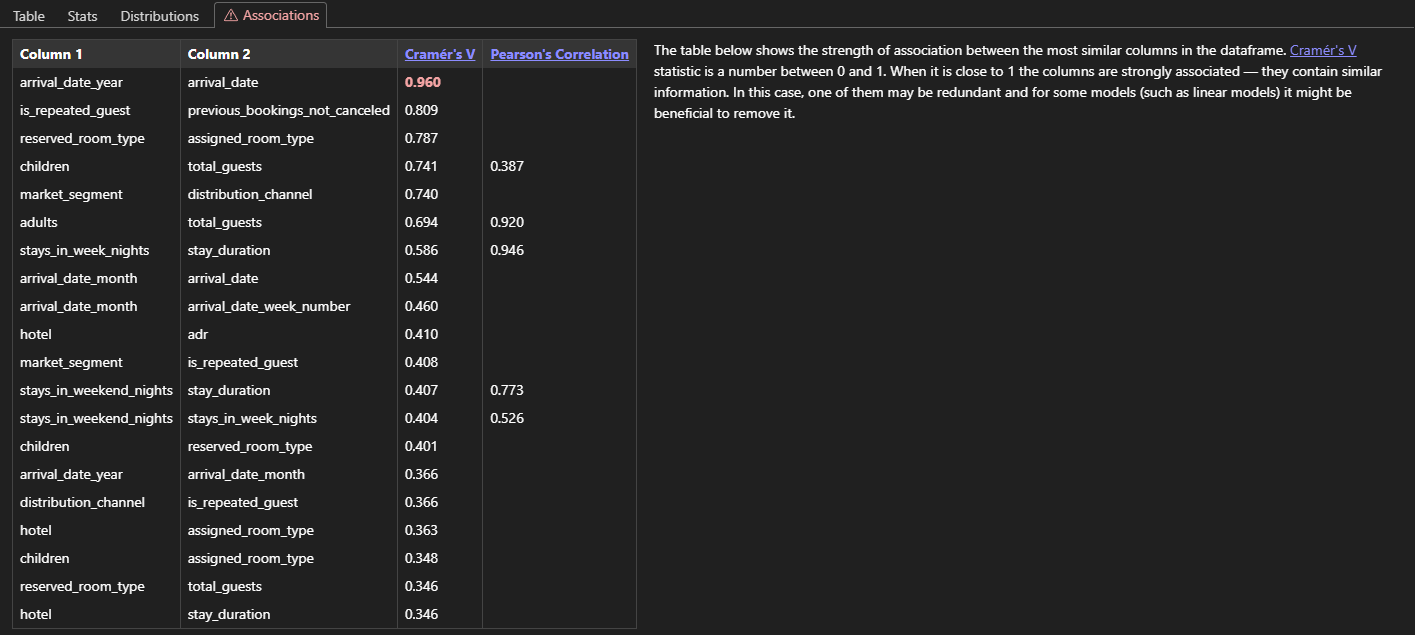

We can see from the table that there are several high correlation between features. Let's try uncover them one by one:
- is_repeated_guest and previous_bookings_not_canceled are logical to be aligned due to the nature of customers' loyalty already proven.
- reserved_room_type and assigned_room_type are also straightforward with only force majeure or on-site requests having big factor in possible changes.
- market_segment and distribution_channel is an interesting one, we'll return to it later.
- children and adults correlating to the total_guests is a given due to them basically a building block for the other feature. The same can be said for other enriched features such as stay_duration with stay_in_week_nights and stay_in_weekend_nights.

These will be a brief overview of each features correlations mentioned above:

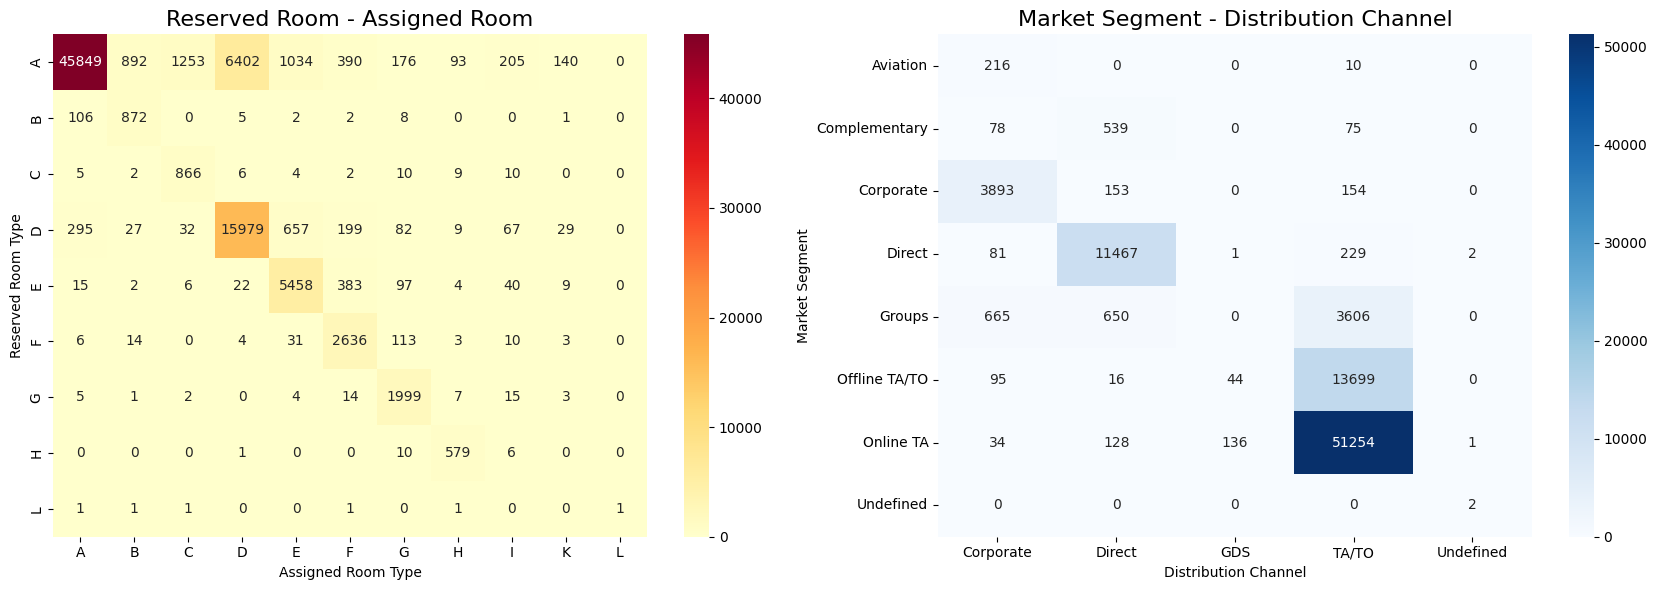

In [33]:
# Hetamap assignment
heat_reserved_assigned = pd.crosstab(df_eda["reserved_room_type"], df_eda["assigned_room_type"])
heat_segment_distribution = pd.crosstab(df_eda["market_segment"], df_eda["distribution_channel"])

# Heatmap rows and columns
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Room Correlation
sns.heatmap(heat_reserved_assigned, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Reserved Room - Assigned Room", fontsize=16)
axes[0].set_xlabel("Assigned Room Type")
axes[0].set_ylabel("Reserved Room Type")

# Market Distribution
sns.heatmap(heat_segment_distribution, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Market Segment - Distribution Channel", fontsize=16)
axes[1].set_xlabel("Distribution Channel")
axes[1].set_ylabel("Market Segment")

plt.tight_layout()
plt.show()


In [34]:
df_eda[["previous_bookings_not_canceled", "is_repeated_guest"]].corr()

,previous_bookings_not_canceled,is_repeated_guest
previous_bookings_not_canceled,1.000000,0.444333
is_repeated_guest,0.444333,1.000000


Several insights:
- As can be seen above, between reserved and assigned room type, there is a clear alignment from A-H room type that decreases in number nearing H. The only abnormality would be the A reserved and E assigned, showing the only out of place number. This also can be seen in the A reserved to B-K, signalling what might be hotels' policy in overbooked room. We can assume A is the most common booked type that overspills to other room types (looking at the assigned numbers) when hotels upgrade customers' booking in overbooked condition.
- For the market_segment and distribution_channel there is no obvious abnormalities like in reserved-assigned room type, simply showing mostly 1:1 correlation to each type.
- For the previous_bookings_not_canceled and is_repeated_guest, it seems simple correlation function does not show any significant relation, though going by the TableReport's cramer score, it can be reasonably inferred some relations (though it is not crucial for analysis or model)
- For other obvious correlating features (stay_duration, total_guests, etc) it won't matter much as their usage is mainly for insight analysis and will be remove during model training.

# Section 5: Data Analysis

In this section we'll dissect many of the features relation to the target using experimental visualization over them. We'll try to get as many insights that might help along the way in making an ML model later on, as well as give the marketing and management team some factors of consideration when reviewing their policies or programs.

### 5.1 Deposit Type Impact upon Cancellation Rate

Deposit type matter a lot in common sense for a customer's decision whether or not to cancel a booking. We must make sure it is the same case within our dataset by at first comparing the real number, then in percentage to see the weights.

In [35]:
depo_raw = df_eda['deposit_type'].value_counts()
depo_percentage = df_eda['deposit_type'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Raw': depo_raw, 'Percent': depo_percentage.round(2)})
summary

,Raw,Percent
deposit_type,,
No Deposit,86084,98.69
Non Refund,1037,1.19
Refundable,107,0.12


As can be seen, the deposit type is dominating hotels' policies by very significant margin in 98%. compared to non-refund in 1% and refundable in 0.1%. This might have an impact to cancellation rate which we'll see next.

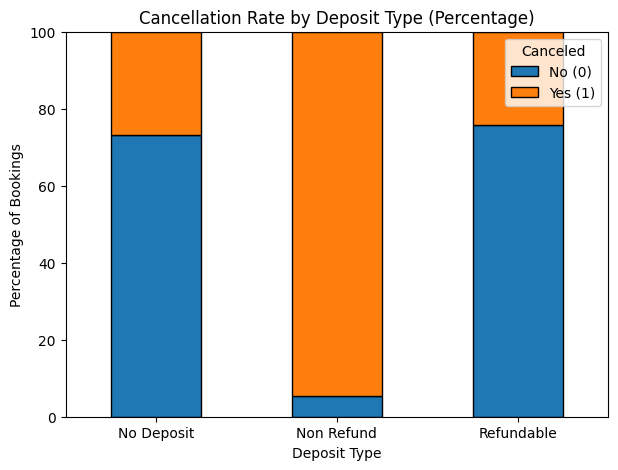

In [36]:
# Setting the colour palette
colourr = {
    0: '#1f77b4',
    1: '#ff7f0e'
}

colourr_str = {
    '0': '#1f77b4',
    '1': '#ff7f0e'
}

# group and normalize to percentages
counts = df_eda.groupby(['deposit_type','is_canceled']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100  # convert to %

# stacked percentage bar chart
percentages.plot(kind='bar', stacked=True, color=[colourr[0],colourr[1]], edgecolor='black', figsize=(7,5))

plt.title("Cancellation Rate by Deposit Type (Percentage)")
plt.xlabel("Deposit Type")
plt.ylabel("Percentage of Bookings")
plt.legend(title="Canceled", labels=['No (0)','Yes (1)'])
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

As no deposit would dwarf other types in the bar plot, we can better see the comparison using their percentage point. An anomaly to common sense appears in the non-refund type as its cancellation rate is so much higher than the other two types, standing at more than 90% compared to no deposit and refundable that hovers around 30%.

In [37]:
df_eda.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).sort_index(ascending=True)

deposit_type  is_canceled
No Deposit    0              0.732819
              1              0.267181
Non Refund    0              0.053038
              1              0.946962
Refundable    0              0.757009
              1              0.242991
Name: proportion, dtype: float64

An important context for this phenomenon would be Portugal's visa requirement of a hotel booking for tourists that is being exploited by Tourism Agency (TA). This would mean TA purposefully booked fictive hotel orders where the conclusive end is a cancellation. This is a distortion of the dataset from outside of the collection and analysis scope, thus making it expendable. We can also see this as a way for hotels' to mitigate such orders by putting it into the non-deposit type, shelving costs by securing the initial payment. It is a minor problem since this type of deposit only make around 1% of the whole dataset. But it might be interesting to see if it's true TA are responsible for this distortion, let's see.

In [38]:
TA_check = df_eda.loc[df_eda['deposit_type'] == 'No Deposit'].groupby('is_canceled')['distribution_channel'].value_counts(normalize=True).unstack(fill_value=0) * 100
TA_check

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
is_canceled,,,,,
0,6.957390,17.378416,0.229852,75.432756,0.001585
1,2.521739,8.156522,0.156522,89.147826,0.017391


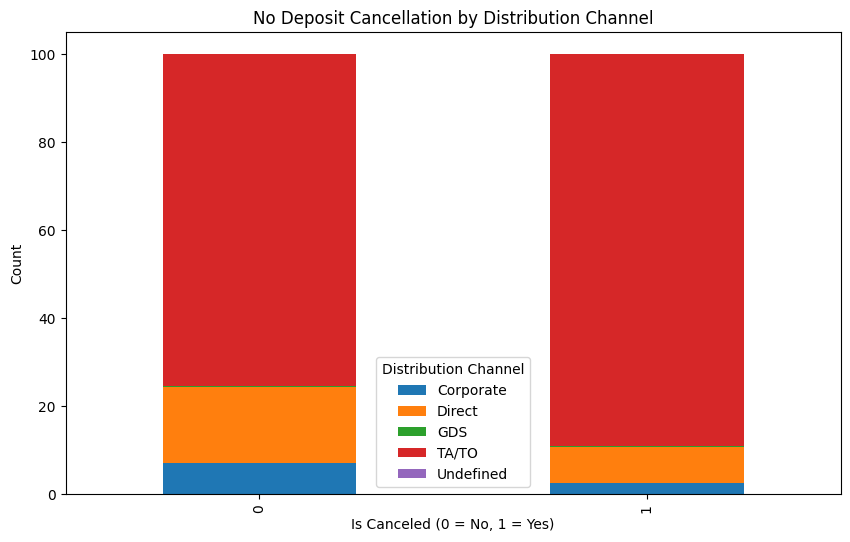

In [39]:
ax = TA_check.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("No Deposit Cancellation by Distribution Channel")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Distribution Channel")
plt.show()

It doesn't show decisively that TA/TO is responsible mainly since the distribution is almost alike. But it can be seen from proportion alone, that in the canceled section, TA/TO gained more number in comparison to the not canceled section. The assumption for the Portugal's visa exploitation distortion can be concluded as reasonable then.

### 5.2 Lead Time's Window of Cancellation

The duration from a customer's booking to the time of the date the booking is for can be an indication of canceling factor. For example it can be assumed that someone booking a year away might have more window of opportunities to consider cancelling their booking. It is of course still an assumption which can be dispelled in the analysis below.

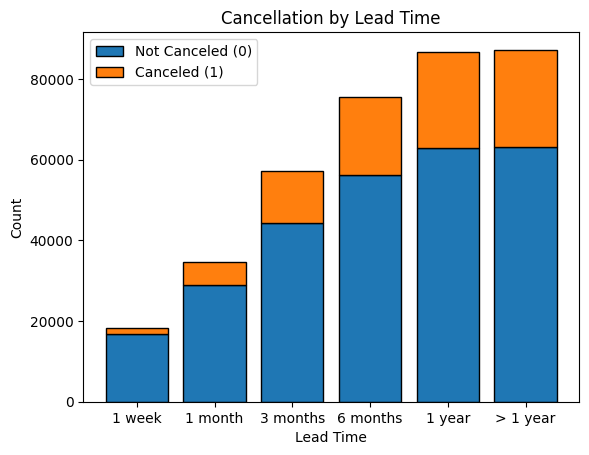

In [40]:
# Making the bins
lead_bins = [7, 30, 90, 180, 365, df_eda["lead_time"].max()]
bin_labels = ['1 week', '1 month', '3 months', '6 months', '1 year', '> 1 year']

# Calculating the cummulative counts
not_canceled = [( (df_eda["lead_time"] <= b) & (df_eda["is_canceled"] == 0) ).sum() for b in lead_bins]
canceled =    [( (df_eda["lead_time"] <= b) & (df_eda["is_canceled"] == 1) ).sum() for b in lead_bins]

# Making the stacked bar chart
plt.bar(bin_labels, not_canceled, label="Not Canceled (0)", color=colourr[0], edgecolor='black')
plt.bar(bin_labels, canceled, bottom=not_canceled, label="Canceled (1)", color=colourr[1], edgecolor='black')

plt.xlabel("Lead Time")
plt.ylabel("Count")
plt.title("Cancellation by Lead Time")
plt.legend()
plt.show()

As is shown in the bar plot, a lead time somewhere less than a week has the least cancellation rate, perhaps considering the short duration between booking and stay time making the decision a sure fire one. In comparison to less than a month, less than 3 months, and within a year, the cancellation rate keep climbing along with the wider window of canceling.

### 5.3 ADR Range Relations to Canceled Guests

We can assume that ADR range would have some impact to customers' relation to cancelling a booking. We can try testing that assumption by making a comparison between customers who cancelled and didn't cancel, then putting it side by side to check if there's any noticable difference.

In [41]:
low, high = df_eda['adr'].quantile([0.01, 0.99])
df_adr = df_eda.copy()
df_adr['adr_capped'] = df_eda['adr'].clip(lower=low, upper=high)
df_adr['adr_capped']

0          0.00
1          0.00
2         75.00
3         75.00
4         98.00
          ...  
87223     96.14
87224    225.43
87225    157.71
87226    104.40
87227    151.20
Name: adr_capped, Length: 87228, dtype: float64

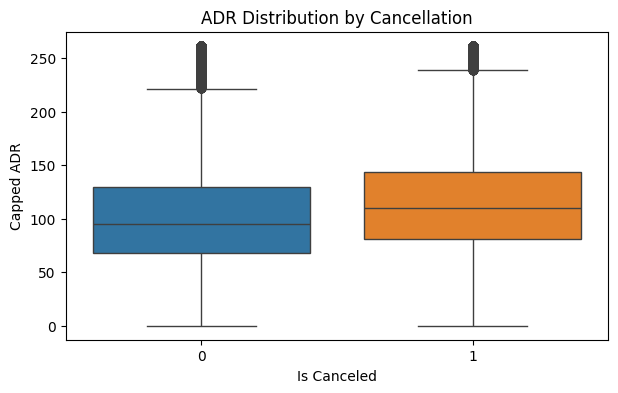

In [42]:
plt.figure(figsize=(7,4))
sns.boxplot(x='is_canceled', y='adr_capped', data=df_adr, palette=colourr_str)
plt.title('ADR Distribution by Cancellation')
plt.xlabel('Is Canceled')
plt.ylabel('Capped ADR')
plt.show()

As can be seen in the boxx plot above, there are no noticeable difference between the two group. They even have significant overlapping at around USD 100 ADR level, the canceling group slightly ahead. What might need further analysis are the outliers that can be seen crowding the end point of the plot, making it rather important for a more decisive conclusion.

### 5.4 Arrival Date and Seasonal Bookings Analysis

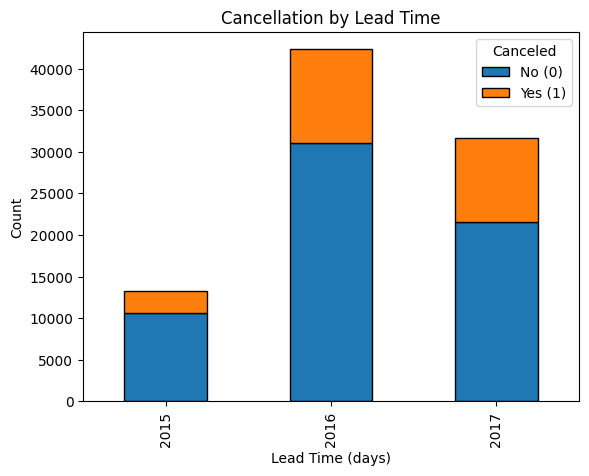

In [43]:
# Group by lead_time_bin and is_canceled, then plot
cancel_by_year = df_eda.groupby(["arrival_date_year", "is_canceled"]).size().unstack(fill_value=0)
cancel_by_year.plot(kind="bar", stacked=True, edgecolor='black')

plt.xlabel("Lead Time (days)")
plt.ylabel("Count")
plt.title("Cancellation by Lead Time")
plt.legend(title="Canceled", labels=['No (0)','Yes (1)'])
plt.show()

The dataset collection time explains why 2016 has the most amount of data compared to 2015 and 2017. It's not that hotels are more booked in 2016, rather that the only full year collecting was done in 2016. In 2015 the collecting started at August, while in 2017 it ended in July. This does mean that comparing between second half of a year (2015) has less cancellation than first half of a year (2017), though the total amount of booking might also explain the discrepancy.

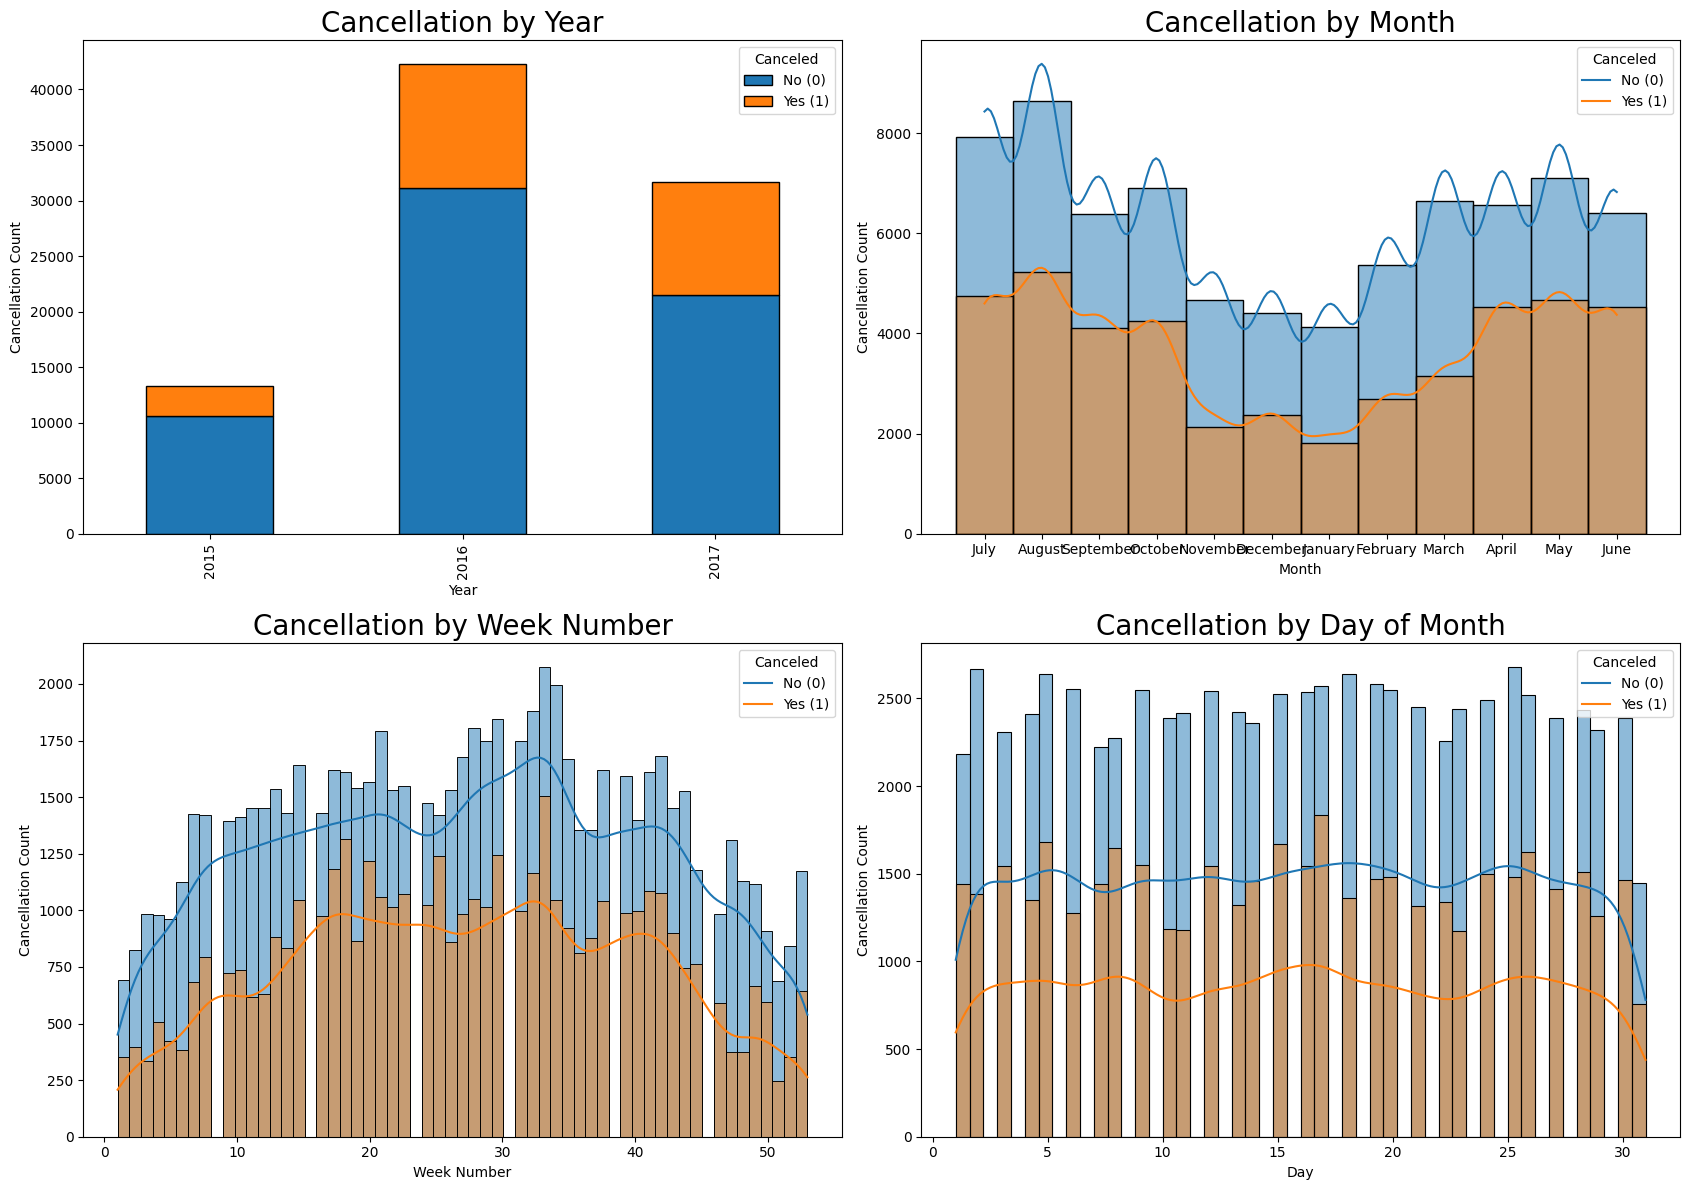

In [44]:
# Group by lead_time_bin and is_canceled, then plot
cancel_by_year = df_eda.groupby(["arrival_date_year", "is_canceled"]).size().unstack(fill_value=0)

# Make figure (modified wow)
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# Barplot of Year
cancel_by_year.plot(kind="bar", stacked=True, ax=axes[0,0], color=colourr, edgecolor='black')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Cancellation Count')
axes[0,0].set_title('Cancellation by Year', fontsize=20)
axes[0,0].legend(title="Canceled", labels=['No (0)','Yes (1)'])

# Histogram month
sns.histplot(data=df, x='arrival_date_month', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[0,1], palette=colourr)
axes[0,1].set_title('Cancellation by Month', fontsize=20)
axes[0,1].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Cancellation Count')

# Histogram week number
sns.histplot(data=df, x='arrival_date_week_number', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[1,0], palette=colourr)
axes[1,0].set_title('Cancellation by Week Number', fontsize=20)
axes[1,0].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Cancellation Count')

# Histogram day of month
sns.histplot(data=df, x='arrival_date_day_of_month', hue='is_canceled', hue_order=[1,0], kde=True, ax=axes[1,1], palette=colourr)
axes[1,1].set_title('Cancellation by Day of Month', fontsize=20)
axes[1,1].legend(title="Canceled", labels=['No (0)','Yes (1)'])
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Cancellation Count')

plt.tight_layout()
plt.show()

In [45]:
# PLaceholder removal column

df_eda.drop(columns=['arrival_date', 'arrival_date_week_number'], inplace=True)

# Section 6: Data Preparation And Feature Engineering

## 6.1 Initialization

In [46]:
df_model = df_eda.copy()
df_model.drop(columns=['stay_duration', 'total_guests'], inplace=True)
df_model

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87223,City Hotel,0,23,2017,August,30,2,5,2,0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,96.14,0,0
87224,City Hotel,0,102,2017,August,31,2,5,3,0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,0,Transient,225.43,0,2
87225,City Hotel,0,34,2017,August,31,2,5,2,0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,157.71,0,4
87226,City Hotel,0,109,2017,August,31,2,5,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,104.40,0,0


In [47]:
display(df.info(), df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [48]:
# Create seen & unseen dataframes

data_seen, data_unseen = train_test_split(df_model, test_size=0.2,
                                          random_state=42,
                                          stratify=df_model["is_canceled"]) 

# data_seen.to_csv("data_train.csv", index=False)
# data_unseen.to_csv("data_test.csv", index=False)

### 6.1.1 Define Feature and Target

In [49]:
# Checking Unique Data Type
categorical_cols = df_model.select_dtypes(include='category').columns.tolist()
numerical_cols = df_model.select_dtypes(include='int64').columns.tolist()

print("Fitur kategorikal:", categorical_cols)
print("Fitur numerik:", numerical_cols)

Fitur kategorikal: ['hotel', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Fitur numerik: ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']


In [50]:
x = data_seen.drop(columns=['is_canceled'])
y = data_seen['is_canceled']

In [51]:
# Creating training and test sets
x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=2021)

### 6.1.2 Create Custome Transformer

Now let’s perform feature encoding for the categorical features in our dataset.  
Here is the plan:

1. Transform the column `arrival_date_month` using **Ordinal Encoding**, since months have a clear natural order from January to December.

2. Transform the columns `hotel`, `meal`, `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, `deposit_type`, and `customer_type` using **One Hot Encoding**, because they are categorical nominal features (no natural order) with a relatively small number of unique values.

3. Transform the column `country` using **Binary Encoding**, because it contains a very large number of unique values (150+ countries). Using One Hot Encoding would create too many new columns, while Binary Encoding keeps the dimensionality low but still preserves information.

4. For the column `deposit_type`, we also apply **One Hot Encoding**, since it only contains three categories (`No Deposit`, `Non Refund`, `Refundable`) and does not have a natural order.

> Note: We need to be cautious, as some encoding techniques may increase the number of features significantly. The above strategy balances interpretability and computational efficiency.


In [52]:
class ColumnCombiner(BaseEstimator, TransformerMixin):
    """
    Combine multiple numeric columns into a single new column.
    Example: adults + children + babies -> total_guests
    """
    def __init__(self, columns=None, new_column_name=None):
        self.columns = columns or []
        self.new_column_name = new_column_name
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        if all(col in X.columns for col in self.columns):
            X[self.new_column_name] = X[self.columns].fillna(0).sum(axis=1)
            X.drop(self.columns, axis=1, inplace=True, errors="ignore")
        return X
    
    def get_feature_names_out(self):
        return [self.new_column_name]
    
class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Drop specified columns if they exist in the DataFrame.
    """
    def __init__(self, columns=None):
        self.columns = columns or []
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[c for c in self.columns if c in X.columns], errors="ignore")
    
class MultiColumnCombiner(BaseEstimator, TransformerMixin):
    """
    Combine multiple sets of columns into new features at once.
    Example:
    combiner = MultiColumnCombiner(
        combinations={
            "total_guests": ["adults", "children", "babies"],
            "total_stay_nights": ["stays_in_weekend_nights", "stays_in_week_nights"]
        }
    )
    """
    def __init__(self, combinations=None):
        self.combinations = combinations or {}
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        for new_col, cols in self.combinations.items():
            if all(c in X.columns for c in cols):
                X[new_col] = X[cols].fillna(0).sum(axis=1)
                X.drop(cols, axis=1, inplace=True, errors="ignore")
        return X
    
    def get_feature_names_out(self):
        return list(self.combinations.keys())

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, whisker=1.5):
        self.columns = columns
        self.whisker = whisker
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.columns:
            if col in X.columns:
                s = pd.to_numeric(X[col], errors="coerce").dropna()
                if len(s) > 0:
                    q1, q3 = s.quantile(0.25), s.quantile(0.75)
                    iqr = q3 - q1
                    self.bounds_[col] = (q1 - self.whisker*iqr, q3 + self.whisker*iqr)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lb, ub) in self.bounds_.items():
            X[col] = pd.to_numeric(X[col], errors="coerce")
            X[col] = X[col].clip(lower=lb, upper=ub).fillna(X[col].median())
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns

class ADRScaler(BaseEstimator, TransformerMixin):
    """Scale adr column using RobustScaler"""
    def __init__(self, column="adr"):
        self.column = column
        self.scaler = RobustScaler()
        self.fitted_ = False
    
    def fit(self, X, y=None):
        if self.column in X.columns:
            self.scaler.fit(X[[self.column]])
            self.fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()
        if self.fitted_ and self.column in X.columns:
            X[self.column] = self.scaler.transform(X[[self.column]])
        return X
    
    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns

class RareLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, tol=0.01, n_categories=1, replace_with="Other"):
        self.tol = tol
        self.n_categories = n_categories
        self.replace_with = replace_with

    def fit(self, X, y=None):
        # pastikan DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        self.columns_ = X.columns
        self.rare_categories_ = {}
        for col in X.columns:
            freqs = X[col].value_counts(normalize=True)
            rare_cats = freqs[freqs < self.tol].index
            if len(freqs) - len(rare_cats) < self.n_categories:
                rare_cats = freqs.sort_values().index[self.n_categories:]
            self.rare_categories_[col] = set(rare_cats)
        return self

    def transform(self, X):
        # pastikan DataFrame
        array_input = False
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.columns_)
            array_input = True

        X_copy = X.copy()
        for col, rare_cats in self.rare_categories_.items():
            X_copy[col] = X_copy[col].where(~X_copy[col].isin(rare_cats), self.replace_with)

        return X_copy.values if array_input else X_copy

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else self.columns_

In [53]:
feature_generator = MultiColumnCombiner(
        combinations={
            "total_guests": ["adults", "children", "babies"],
            "total_stay_nights": ["stays_in_weekend_nights", "stays_in_week_nights"]
        }
    )
feature_dropper = ColumnDropper(columns=['arrival_date_week_number', 'agent', 'company', 'reservation_status', 'reservation_status_date','assigned_room_type','arrival_date_year','meal'])

display(feature_generator.fit_transform(x_train).head(1))
display(feature_dropper.fit_transform(x_train).head(1))


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay_nights
645,Resort Hotel,33,2015,July,25,HB,PRT,Online TA,TA/TO,0,0,0,C,C,0,No Deposit,0,Transient,142.03,0,1,4,5


,hotel,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
645,Resort Hotel,33,July,25,2,3,2,2,0,PRT,Online TA,TA/TO,0,0,0,C,0,No Deposit,0,Transient,142.03,0,1


In [54]:
# Define month ordering for OrdinalEncoder
month_order = [['January','February','March','April','May','June',
                'July','August','September','October','November','December']]

In [55]:
# Define transformers
transformer = ColumnTransformer([
    # One Hot Encoding for nominal small-cardinality features
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
     ['hotel', 'meal', 'market_segment', 'distribution_channel',
      'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']),
    
    # Ordinal Encoding for months
    ('ordinal', OrdinalEncoder(categories=month_order), ['arrival_date_month']),
    
    # Binary Encoding for high-cardinality 'country'
    ('binary', ce.BinaryEncoder(), ['country'])
    
], remainder='passthrough')

## 6.2 Feature Engineering Setup

In [56]:
# =============================
#  Numerical Features Pipeline
# =============================
num_pipeline = Pipeline([
    ("clipper", OutlierClipper(columns=["adr"], whisker=3.0)),  # handle outliers
    ("scaler", ADRScaler())  # robust scaling on ADR
])

# ==================================
#  Categorical Features Pipeline (OHE)
# ==================================
ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# ==================================
#  Categorical Features Pipeline (Binary)
# ==================================
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ce.BinaryEncoder())
])

# ==================================
#  Categorical Features Pipeline (Ordinal)
# ==================================
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=month_order))   # dari sklearn.preprocessing
])

display(num_pipeline, ohe_pipeline, binary_pipeline, ordinal_pipeline)

,steps,"[('clipper', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,columns,['adr']
,whisker,3.0
,column,'adr'


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,verbose,0


,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['January', 'February', ...]]"


In [57]:
# Rare Label OHE Pipeline
rare_ohe_pipeline = clone(ohe_pipeline)
rare_ohe_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

# Rare Label Binary Pipeline
rare_binary_pipeline = clone(binary_pipeline)
rare_binary_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

# Rare Label Ordinal Pipeline (opsional, kalau ada kategori ordinal yang terlalu banyak)
rare_ordinal_pipeline = clone(ordinal_pipeline)
rare_ordinal_pipeline.steps.insert(1, ("rare_encoder", RareLabelEncoder(tol=0.01, n_categories=1, replace_with="Other")))

display(rare_ohe_pipeline, rare_binary_pipeline, rare_ordinal_pipeline)


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


,steps,"[('imputer', ...), ('rare_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,tol,0.01


In [58]:
num_features = [
    "lead_time", 
    "arrival_date_day_of_month",
    "total_stay_nights",         # hasil combine stays
    "total_guests",              # hasil combine guests
    "previous_cancellations", 
    "previous_bookings_not_canceled", 
    "booking_changes", 
    "days_in_waiting_list", 
    "adr", 
    "required_car_parking_spaces", 
    "total_of_special_requests"
]

ohe_features = [
    "hotel", 
    "market_segment", 
    "distribution_channel", 
    "reserved_room_type", 
    "deposit_type", 
    "customer_type"
]

binary_features = [
    "country"
]

ordinal_features = [
    "arrival_date_month"
]

In [59]:
# Baseline Preprocessor
baseline_preprocessor = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_features),
    ("ohe_pipeline", ohe_pipeline, ohe_features),
    ("binary_pipeline", binary_pipeline, binary_features)
], remainder="drop", verbose_feature_names_out=False)

# Baseline Preprocessor + Rare Label Encoding
rare_preprocessor = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_features),
    ("ohe_pipeline", rare_ohe_pipeline, ohe_features),
    ("binary_pipeline", rare_binary_pipeline, binary_features)
], remainder="drop", verbose_feature_names_out=False)

In [60]:
display(baseline_preprocessor, rare_preprocessor)

,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,columns,['adr']
,whisker,3.0
,column,'adr'


,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,columns,['adr']
,whisker,3.0
,column,'adr'


In [61]:
# # Define transformers
# transformer = ColumnTransformer([
#     # One Hot Encoding for nominal small-cardinality features
#     ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
#      ['hotel', 'meal', 'market_segment', 'distribution_channel',
#       'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']),
    
#     # Ordinal Encoding for months
#     ('ordinal', OrdinalEncoder(categories=month_order), ['arrival_date_month']),
    
#     # Binary Encoding for high-cardinality 'country'
#     ('binary', ce.BinaryEncoder(), ['country'])
    
# ], remainder='passthrough')

## 6.3 Feature Engineering Overview

In [62]:
x_train_pre = feature_generator.fit_transform(x_train)
x_train_pre = baseline_preprocessor.fit_transform(x_train_pre)
fe_overview = pd.DataFrame(x_train_pre, columns=baseline_preprocessor.get_feature_names_out())

In [63]:
print("Before Preprocessing:")
display(x_train.head(1))

print("After Preprocessing:")
display(fe_overview.head(1))

Before Preprocessing:


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
645,Resort Hotel,33,2015,July,25,2,3,2,2,0,HB,PRT,Online TA,TA/TO,0,0,0,C,C,0,No Deposit,0,Transient,142.03,0,1


After Preprocessing:


,lead_time,arrival_date_day_of_month,total_stay_nights,total_guests,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,0_0,0_1,0_2,0_3,0_4,0_5,0_6,0_7
0,33.0,25.0,5.0,4.0,0.0,0.0,0.0,0.0,0.699275,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [64]:
x_train_pre = feature_generator.fit_transform(x_train)
x_train_pre = rare_preprocessor.fit_transform(x_train_pre)
fe_overview = pd.DataFrame(x_train_pre, columns=rare_preprocessor.get_feature_names_out())

In [65]:
# testing = pd.DataFrame(transformer.fit_transform(x_train),columns=transformer.get_feature_names_out())
# testing.head()

# Section 7: Model Development

In [66]:
# Individual Models (Baseline)
models = {
    "Baseline Model": DummyClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest Classifiers": RandomForestClassifier(random_state=42),
    "Adaboost Classifier": AdaBoostClassifier(random_state=42),
    "XGBoost Classifier": XGBClassifier(random_state=42)
}

In [67]:
def business_impact_score(y_true, y_pred, 
                                cost_fn=450, cost_fp=200, value_tp=450,
                                adr=None, stay_nights=None):
    """
    Custom business impact metric for hotel booking cancellations.
    
    Parameters:
    - y_true: True labels (0 = Not Canceled, 1 = Canceled)
    - y_pred: Predicted labels (0 or 1)
    - cost_fn: Cost of missing a cancellation (False Negative)
    - cost_fp: Cost of wrongly flagging a valid booking as canceled (False Positive)
    - value_tp: Value saved per correctly detected cancellation (True Positive)
    - adr: Optional array of ADR (Average Daily Rate) for scaling by actual booking value
    - stay_nights: Optional array of total stay nights for scaling
    
    Returns:
    - net_impact: Net business impact (the higher, the better)
    """
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    if adr is not None and stay_nights is not None:
        # Calculate actual revenue impact per booking
        tp_value = np.sum([a*s for yt, yp, a, s in zip(y_true, y_pred, adr, stay_nights) if yt==1 and yp==1])
        fn_loss  = np.sum([a*s for yt, yp, a, s in zip(y_true, y_pred, adr, stay_nights) if yt==1 and yp==0])
    else:
        tp_value = tp * value_tp
        fn_loss  = fn * cost_fn
    
    fp_loss = fp * cost_fp
    
    net_impact = tp_value - fn_loss - fp_loss
    return net_impact

# Make scorer for sklearn (higher is better)
hotel_business_scorer = make_scorer(business_impact_score, greater_is_better=True)

# Initialize the metrics

main_metrics = "average_precision_score" # PR-AUC
business_scorer = make_scorer(
    business_impact_score,
    greater_is_better=True,  # karena kita ingin nilai impact makin besar
)


In [68]:
def business_impact_score(y_true, y_pred, adr, stay_nights, 
                          cost_fp=200):
    """
    Business impact score for hotel bookings, scaled by actual booking value.
    
    Parameters:
    - y_true: True labels (0 = Not Canceled, 1 = Canceled)
    - y_pred: Predicted labels (0 or 1)
    - adr: Array-like, Average Daily Rate per booking
    - stay_nights: Array-like, total nights stayed per booking
    - cost_fp: Cost of wrongly flagging a valid booking as canceled
    
    Returns:
    - net_impact: Net business impact (higher is better)
    """
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate actual monetary value of bookings
    booking_values = np.array(adr) * np.array(stay_nights)
    
    # Revenue saved: correctly predicted cancellations
    tp_value = np.sum([val for yt, yp, val in zip(y_true, y_pred, booking_values) if yt==1 and yp==1])
    
    # Revenue lost: missed cancellations (FN)
    fn_loss  = np.sum([val for yt, yp, val in zip(y_true, y_pred, booking_values) if yt==1 and yp==0])
    
    # Reputation / opportunity loss: FP × fixed cost
    fp_loss  = fp * cost_fp
    
    net_impact = tp_value - fn_loss - fp_loss
    return net_impact

# Initialize metrics
main_metrics = "average_precision_score"  # PR-AUC
business_scorer = make_scorer(
    business_impact_score,
    greater_is_better=True
)


In [69]:
# Example data
y_true = [0, 1, 1, 0]
y_pred = [0, 0, 1, 1]
adr = [100, 120, 80, 90]            # ADR per booking
stay_nights = [2, 3, 4, 1]          # stay nights per booking

print(f"PR-AUC: {average_precision_score(y_true, y_pred)}")
print(f"Business Impact: {business_impact_score(y_true, y_pred, adr, stay_nights)}")


PR-AUC: 0.5
Business Impact: -240


In [70]:
# Main function

def benchmark_models(models: dict, pipeline: Pipeline|ImbPipeline, 
                     X, y, cv=5, scoring_metrics=None, return_raw=False):
    """
    Run cross-validated benchmarking across multiple models.

    Parameters:
    - models: dict of {model_name: model_object}
    - X: Features
    - y: Target labels
    - cv: Cross-validation folds (int or CV splitter)
    - scoring_metrics: dict of scorers (default: PR-AUC and Business Impact)
    - return_raw: if True, returns full raw result dictionary

    Returns:
    - DataFrame with mean and std of each metric per model
    """
    if scoring_metrics is None:
        scoring_metrics = {
            "pr_auc": "average_precision",
            "business_impact": business_scorer}

    results = []

    for name, model in models.items():
        print(f"Evaluating {name}...    ", end="")
        clf = clone(pipeline) # ensure independence
        clf.set_params(classifier=model)
        cv_result = cross_validate(
            clf,
            X, y,
            cv=cv,
            scoring=scoring_metrics,
            return_train_score=True,
            n_jobs=-1
        )

        result_summary = {
            "Model": name
        }

        for metric_key in scoring_metrics:
            train_scores = cv_result[f'train_{metric_key}']
            result_summary[f"Train {metric_key.upper()} Mean"] = np.mean(train_scores)
            result_summary[f"Train {metric_key.upper()} Std"] = np.std(train_scores)

            test_scores = cv_result[f'test_{metric_key}']
            result_summary[f"Test {metric_key.upper()} Mean"] = np.mean(test_scores)
            result_summary[f"Test {metric_key.upper()} Std"] = np.std(test_scores)

            result_summary["Fit Time Mean"] = np.mean(cv_result["fit_time"])
            result_summary["Score Time Mean"] = np.mean(cv_result["score_time"])

        if return_raw:
            result_summary["Raw"] = cv_result

        results.append(result_summary)

        print("Done!")

    return pd.DataFrame(results).sort_values(by="Test PR_AUC Mean", ascending=False)


# 7.2 Pipeline Setup

In [71]:
# Baseline Pipeline
baseline_pipeline = ImbPipeline([
    ("feature_generator", feature_generator),
    ("preprocessor", baseline_preprocessor),
    ("classifier", models["Baseline Model"])
])

baseline_pipeline

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [72]:
# Advance Pipeline

# Baseline Pipeline + Resample
baseline_pipeline_resample = ImbPipeline([
    ("feature_generator", feature_generator),
    ("preprocessor", baseline_preprocessor),
    ("resample", SMOTE(random_state=42)),
    ("classifier", models["Baseline Model"])
])

baseline_pipeline_resample

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [73]:
# Pipeline Testing

cv_result = cross_validate(
    baseline_pipeline,
    x_train, y_train,
    cv=5,
    scoring={"pr_auc": "average_precision",
             "business_impact": business_scorer},
    return_train_score=True
)
cv_result

{'fit_time': array([0.12844658, 0.11253953, 0.11008239, 0.11113596, 0.10924459]),
 'score_time': array([0.05788136, 0.04277873, 0.0435245 , 0.04565477, 0.0416255 ]),
 'test_pr_auc': array([0.27523511, 0.27523511, 0.27523511, 0.27523511, 0.27523511]),
 'train_pr_auc': array([0.27523511, 0.27523511, 0.27523511, 0.27523511, 0.27523511]),
 'test_business_impact': array([nan, nan, nan, nan, nan]),
 'train_business_impact': array([nan, nan, nan, nan, nan])}

## 7.3 Model Benchmarking
Select best model based on cross-validation result

In [74]:
# Model benchmarking using Stratified K-Fold
sf = StratifiedKFold(n_splits=5)

### Experiment 1. Select Best Preprocessor

In [75]:
# 1.1 Baseline Preprocessing
bcmk_baseline = benchmark_models(models, baseline_pipeline, 
                                 x_train, y_train, cv=sf)

Evaluating Baseline Model...    Done!
Evaluating Decision Tree Classifier...    Done!
Evaluating Logistic Regression...    Done!
Evaluating Random Forest Classifiers...    Done!
Evaluating Adaboost Classifier...    Done!
Evaluating XGBoost Classifier...    Done!


In [76]:
bcmk_baseline[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]]

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
5,XGBoost Classifier,0.739602,0.768012,0.099994
3,Random Forest Classifiers,0.732659,4.065088,0.359570
4,Adaboost Classifier,0.620426,2.343761,0.201352
2,Logistic Regression,0.611995,0.749816,0.070310
1,Decision Tree Classifier,0.437746,0.385144,0.061402
0,Baseline Model,0.275235,0.146596,0.055852


Top 3 Model
1. XBboost Classifier
2. Random Forest Calssifier
3. Adaboost Classifier

Train with 
- 1.2 Baseline with Rare Label Handing 

In [77]:
top_model = ["Random Forest Classifiers", "XGBoost Classifier", "Adaboost Classifier"]

model_candidate = models.copy()
model_candidate = {k: model_candidate[k] for k in model_candidate if k in top_model}

In [78]:
# 1.3 Baseline Preprocessing with Rare Label handling

baseline_rare = clone(baseline_pipeline)
baseline_rare.set_params(preprocessor = rare_preprocessor)

bmck_baseline_rare = benchmark_models(model_candidate, baseline_rare, 
                                      x_train, y_train, cv=sf)

Evaluating Random Forest Classifiers...    Done!
Evaluating Adaboost Classifier...    Done!
Evaluating XGBoost Classifier...    Done!


In [79]:
bmck_baseline_rare[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]]

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
2,XGBoost Classifier,0.740208,0.515758,0.104445
0,Random Forest Classifiers,0.732214,3.966891,0.377639
1,Adaboost Classifier,0.630463,2.068609,0.184688


In [80]:
all_experiment = [
    bcmk_baseline.head(3),
    bmck_baseline_rare.head(3),
]


summary = pd.concat(all_experiment).sort_values("Test PR_AUC Mean", ascending=False)
summary[["Model", "Test PR_AUC Mean","Fit Time Mean","Score Time Mean"]].head(3)

,Model,Test PR_AUC Mean,Fit Time Mean,Score Time Mean
2,XGBoost Classifier,0.740208,0.515758,0.104445
5,XGBoost Classifier,0.739602,0.768012,0.099994
3,Random Forest Classifiers,0.732659,4.065088,0.359570


Best Model
1. XGBoost Classifier
2. RandomForest 

### Experiment 2. Try with Resampling

In [81]:
#### Model 1. XGBoost

Before Resampling (Evaluate on Data Testing)

In [82]:
# Model 1: XGBoost Baseline Classifier

xgb_baseline = clone(baseline_pipeline)
xgb_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = models["XGBoost Classifier"])
xgb_baseline.fit(x_train, y_train)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [83]:
# Predict and Score
pred_train = xgb_baseline.predict(x_train)
pred_test = xgb_baseline.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.5994925966846973
Test PR-AUC:  0.5380494534125598
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     40460
           1       0.78      0.64      0.70     15365

    accuracy                           0.85     55825
   macro avg       0.83      0.79      0.80     55825
weighted avg       0.85      0.85      0.85     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     10116
           1       0.72      0.59      0.65      3841

    accuracy                           0.82     13957
   macro avg       0.79      0.75      0.77     13957
weighted avg       0.82      0.82      0.82     13957



After Resampling (Evaluate on Data Testing)

In [84]:
resampler = {
    "SMOTE": SMOTE(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Near Miss": NearMiss()
}

In [85]:
# Model 1: XGBoost Baseline Classifier
# Experiment 2. Try different resampling

xgb_baseline = clone(baseline_pipeline_resample)
xgb_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = XGBClassifier(random_state=42))


,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [86]:
search_resampler_xgboost = GridSearchCV(
    estimator=xgb_baseline,
    param_grid={"resample": list(resampler.values())},
    scoring="average_precision",
    cv=sf,
    return_train_score=True,
    verbose = 1
)

search_resampler_xgboost.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'resample': [SMOTE(random_state=42), RandomOverSam...ndom_state=42), ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [87]:
search_resampler_xgboost.best_params_

{'resample': SMOTE(random_state=42)}

In [88]:
pd.DataFrame(search_resampler_xgboost.cv_results_).sort_values("mean_test_score", ascending=False)[["params","mean_score_time","mean_test_score"]].head(4)

,params,mean_score_time,mean_test_score
0,{'resample': SMOTE(random_state=42)},0.031468,0.742514
1,{'resample': RandomOverSampler(random_state=42)},0.030573,0.740478
2,{'resample': RandomUnderSampler(random_state=42)},0.030056,0.733261
3,{'resample': NearMiss()},0.031434,0.524820


In [89]:
# Predict and Score
pred_train_resample = search_resampler_xgboost.best_estimator_.predict(x_train)
pred_test_resample = search_resampler_xgboost.best_estimator_.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_resample))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_resample))

Train PR-AUC:  0.5880069825428627
Test PR-AUC:  0.53799899175378
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.87      0.92      0.90     40460
           1       0.76      0.65      0.70     15365

    accuracy                           0.85     55825
   macro avg       0.81      0.79      0.80     55825
weighted avg       0.84      0.85      0.84     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.71      0.61      0.65      3841

    accuracy                           0.82     13957
   macro avg       0.78      0.76      0.77     13957
weighted avg       0.82      0.82      0.82     13957



In [90]:
print("Summary XGB Baseline Classifier")
print("\nBefore Tunning:")
print("Train PR-AUC: ", average_precision_score(y_train, pred_train))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test))

print("\nAfter Tunning:")
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample))

Summary XGB Baseline Classifier

Before Tunning:
Train PR-AUC:  0.5994925966846973
Test PR-AUC:  0.5380494534125598

After Tunning:
Train PR-AUC:  0.5880069825428627
Test PR-AUC:  0.53799899175378


#### Model 2. Random Forest

Before Resampling

In [91]:
# Model 2: Random Forest Baseline Classifier

rf_baseline = clone(baseline_pipeline)
rf_baseline.set_params(preprocessor = baseline_preprocessor,
                        classifier = models["Random Forest Classifiers"])
rf_baseline.fit(x_train, y_train)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [92]:
# Predict and Score
pred_train = rf_baseline.predict(x_train)
pred_test = rf_baseline.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.9925408642442157
Test PR-AUC:  0.5348590935012487
Classification Report (Train): 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40460
           1       1.00      0.99      1.00     15365

    accuracy                           1.00     55825
   macro avg       1.00      1.00      1.00     55825
weighted avg       1.00      1.00      1.00     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.85      0.92      0.88     10116
           1       0.72      0.58      0.64      3841

    accuracy                           0.82     13957
   macro avg       0.79      0.75      0.76     13957
weighted avg       0.82      0.82      0.82     13957



After Resampling

In [93]:
# Model 2: Random Forest Baseline Classifier + Grouping Transaction

rf_baseline_resample = clone(baseline_pipeline_resample)
rf_baseline_resample.set_params(preprocessor = baseline_preprocessor,
                        classifier = models["Random Forest Classifiers"])

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [94]:
search_resampler_rf = GridSearchCV(
    estimator=rf_baseline_resample,
    param_grid={"resample": list(resampler.values())},
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_resampler_rf.fit(x_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'resample': [SMOTE(random_state=42), RandomOverSam...ndom_state=42), ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [95]:
search_resampler_rf.best_params_

{'resample': SMOTE(random_state=42)}

In [96]:
search_resampler_rf.best_score_

np.float64(0.7259600111613895)

In [97]:
pd.DataFrame(search_resampler_rf.cv_results_).sort_values("mean_test_score", ascending=False)[["params","mean_score_time","mean_test_score"]].head(4)

,params,mean_score_time,mean_test_score
0,{'resample': SMOTE(random_state=42)},0.170593,0.725960
1,{'resample': RandomOverSampler(random_state=42)},0.170908,0.721963
2,{'resample': RandomUnderSampler(random_state=42)},0.144800,0.716175
3,{'resample': NearMiss()},0.140582,0.592069


In [98]:
# Predict and Score
pred_train_resample = search_resampler_rf.best_estimator_.predict(x_train)
pred_test_resample = search_resampler_rf.best_estimator_.predict(x_test)

# PR-AUC Score
print("Train PR-AUC: ", average_precision_score(y_train, pred_train_resample))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_resample))

# Classification Report
print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_resample))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_resample))

Train PR-AUC:  0.9925705560755904
Test PR-AUC:  0.536732188895543
Classification Report (Train): 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40460
           1       1.00      0.99      1.00     15365

    accuracy                           1.00     55825
   macro avg       1.00      1.00      1.00     55825
weighted avg       1.00      1.00      1.00     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.71      0.60      0.65      3841

    accuracy                           0.82     13957
   macro avg       0.78      0.75      0.77     13957
weighted avg       0.82      0.82      0.82     13957



## 7.4 Tunning Model

Best Model: Xgboost Baseline Classfier with Resampling (SMOTE)

In [99]:
# Final Model
# XGboost Baseline Classifier with Undersampling

final_model = clone(baseline_pipeline_resample)
final_model.set_params(preprocessor = baseline_preprocessor,
                       resample = resampler["SMOTE"],
                       classifier = models["XGBoost Classifier"])
final_model.fit(x_train, y_train)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [100]:
final_model.named_steps["classifier"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

#### 7.4.2 Searching Best Parameters (Hyperparameter Tunning) #1

Experiment #1
- N Estimators (100, 1000)
- Learning Rate (0.1, 0.01)
- Maximum Depth (3, 9)

In [101]:
param_dist = {
    "classifier__n_estimators": [100, 1000, None],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__max_depth": [3, 9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.01, 0.1], 'classifier__max_depth': [3, 9], 'classifier__n_estimators': [100, 1000, ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [102]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.01, 'classifier__max_depth': 9, 'classifier__n_estimators': 1000}
0.7409712636223645


#### 7.4.2 Searching Best Parameters (Hyperparameter Tunning) #2

In [103]:
param_dist = {
    "classifier__n_estimators": [1000, 500],
    "classifier__learning_rate": [0.01, 0.05],
    "classifier__max_depth": [5, 9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.01, 0.05], 'classifier__max_depth': [5, 9], 'classifier__n_estimators': [1000, 500]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [104]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 500}
0.7491709289034747


#### 7.4.2 Searching Best Parameters (Hyperparameter Tunning) #3

In [105]:
param_dist = {
    "classifier__n_estimators": [500, 700],
    "classifier__learning_rate": [0.03, 0.05, 0.07],
    "classifier__max_depth": [9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [9], 'classifier__n_estimators': [500, 700]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [106]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 700}
0.7491754709929164


In [107]:
param_dist = {
    "classifier__n_estimators": [600, 700, 800],
    "classifier__learning_rate": [0.05],
    "classifier__max_depth": [9]
}

search_best_model = GridSearchCV(
    estimator=final_model,
    param_grid=param_dist,
    scoring="average_precision",
    cv=sf,
    return_train_score=True
)

search_best_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.05], 'classifier__max_depth': [9], 'classifier__n_estimators': [600, 700, ...]}"
,scoring,'average_precision'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"


In [108]:
print(search_best_model.best_params_)
print(search_best_model.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 700}
0.7491754709929164


OK, so we get the following:
- Learning Rate = 0.05
- Max Depth = 9
- n Estimator = 700

for the best parameter 

In [109]:
final_model = clone(baseline_pipeline_resample)
final_model.set_params(preprocessor = baseline_preprocessor,
                       resample = resampler["Near Miss"],
                       classifier = models["XGBoost Classifier"])
final_model.fit(x_train, y_train)

pred_train = final_model.predict(x_train)
pred_test = final_model.predict(x_test)

print("Train PR-AUC: ", average_precision_score(y_train, pred_train))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test))

print("Classification Report (Train): ")
print(classification_report(y_train, pred_train))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test))

Train PR-AUC:  0.44614841889577733
Test PR-AUC:  0.42365259464872007
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.91      0.66      0.76     40460
           1       0.48      0.83      0.61     15365

    accuracy                           0.71     55825
   macro avg       0.70      0.75      0.69     55825
weighted avg       0.79      0.71      0.72     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.89      0.65      0.75     10116
           1       0.46      0.80      0.58      3841

    accuracy                           0.69     13957
   macro avg       0.68      0.72      0.67     13957
weighted avg       0.77      0.69      0.70     13957



In [110]:
final_model_tuned = clone(search_best_model.best_estimator_)
final_model_tuned.fit(x_train, y_train)

pred_train_tuned = final_model_tuned.predict(x_train)
pred_test_tuned = final_model_tuned.predict(x_test)

print("Train PR-AUC: ", average_precision_score(y_train, pred_train_tuned))
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_tuned))

print("Classification Report (Train): ")
print(classification_report(y_train, pred_train_tuned))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_tuned))

Train PR-AUC:  0.7237311130211559
Test PR-AUC:  0.5480666215643676
Classification Report (Train): 
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     40460
           1       0.86      0.77      0.81     15365

    accuracy                           0.90     55825
   macro avg       0.89      0.86      0.87     55825
weighted avg       0.90      0.90      0.90     55825

Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.72      0.62      0.66      3841

    accuracy                           0.83     13957
   macro avg       0.79      0.76      0.77     13957
weighted avg       0.82      0.83      0.82     13957



## 7.5 Model Analysis

In [111]:
### 7.5.1 Evaluate on Testing Model

In [112]:
pred_test_tuned = final_model_tuned.predict(x_test)
print("Test PR-AUC: ", average_precision_score(y_test, pred_test_tuned))
print("Classification Report (Test): ")
print(classification_report(y_test, pred_test_tuned))

Test PR-AUC:  0.5480666215643676
Classification Report (Test): 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.72      0.62      0.66      3841

    accuracy                           0.83     13957
   macro avg       0.79      0.76      0.77     13957
weighted avg       0.82      0.83      0.82     13957



### 7.5.2 Residual Analysis

#### Confusion Matrix Inspection

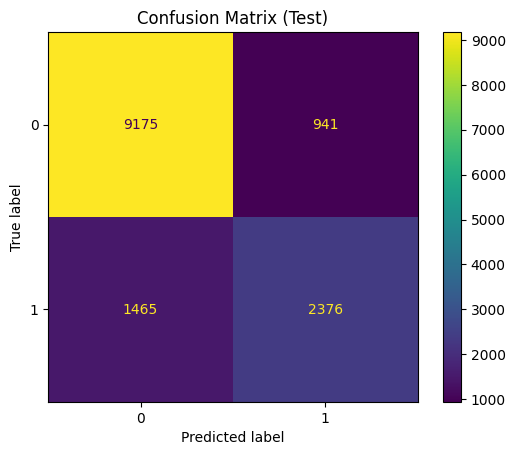

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(final_model_tuned, x_test, y_test)
plt.title("Confusion Matrix (Test)")
plt.show()

#### Classification Report

In [114]:
print("PR-AUC: ", average_precision_score(y_test, pred_test_tuned))
print("Classification Report: ")
print(classification_report(y_test, pred_test_tuned))

PR-AUC:  0.5480666215643676
Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     10116
           1       0.72      0.62      0.66      3841

    accuracy                           0.83     13957
   macro avg       0.79      0.76      0.77     13957
weighted avg       0.82      0.83      0.82     13957



#### Weak Performance Analysis

In [115]:
def weak_performance_analysis(model, x_test, y_test, feature_df=None, target_names=None):
    """
    Analisis performa buruk dari model klasifikasi.
    
    Parameters:
    - model: trained sklearn model
    - X_test: features untuk testing
    - y_test: target aslinya
    - feature_df: DataFrame asli dari X_test (untuk analisis subgroup)
    - target_names: nama dari kelas target
    """
    y_pred = model.predict(x_test)

    # 1. Error Analysis
    errors = y_pred != y_test
    print(f"\nTotal Errors: {np.sum(errors)} / {len(y_test)}")
    error_rate = np.mean(errors)
    print(f"Error Rate: {error_rate:.2%}")

    # 2. Analisis per Kelas
    print("\n=== Weak Class Performance ===")
    report = classification_report(y_test, y_pred, output_dict=True)
    class_df = pd.DataFrame(report).T
    weak_classes = class_df[(class_df.index != 'accuracy') & (class_df['f1-score'] < 0.6)]
    print(weak_classes[['precision', 'recall', 'f1-score']])

    # 3. Optional: Analisis berdasarkan fitur/segmentasi
    if feature_df is not None:
        print("\n=== Segment-wise Error Rate ===")
        feature_df = feature_df.copy()
        feature_df['actual'] = y_test
        feature_df['predicted'] = y_pred
        feature_df['error'] = feature_df['actual'] != feature_df['predicted']

        for col in feature_df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n>> Error rate by '{col}':")
            print(
                feature_df.groupby(col)['error']
                .mean()
                .sort_values(ascending=False)
                .apply(lambda x: f"{x:.2%}")
            )



In [116]:
# Weak Performance Analysis

weak_performance_analysis(final_model_tuned, x_test, y_test, feature_df=x_test, target_names=["Not Canceled", "is Canceled"])


Total Errors: 2406 / 13957
Error Rate: 17.24%

=== Weak Class Performance ===
Empty DataFrame
Columns: [precision, recall, f1-score]
Index: []

=== Segment-wise Error Rate ===

>> Error rate by 'hotel':
hotel
City Hotel      19.97%
Resort Hotel    12.98%
Name: error, dtype: object

>> Error rate by 'arrival_date_year':
arrival_date_year
2017    21.16%
2016    16.27%
2015    11.15%
Name: error, dtype: object

>> Error rate by 'arrival_date_month':
arrival_date_month
August       21.17%
April        20.91%
July         19.52%
June         17.79%
December     17.41%
March        17.26%
May          16.01%
September    15.89%
February     14.88%
January      13.74%
November     13.34%
October      12.67%
Name: error, dtype: object

>> Error rate by 'arrival_date_day_of_month':
arrival_date_day_of_month
10    21.90%
25    21.84%
26    20.25%
9     19.74%
7     18.78%
27    18.43%
3     18.28%
14    18.25%
22    17.88%
4     17.79%
21    17.74%
2     17.74%
20    17.69%
16    17.34%
6     1

### 7.5.3 Learning Curve Inspection

In [117]:
# %pip install deepchecks

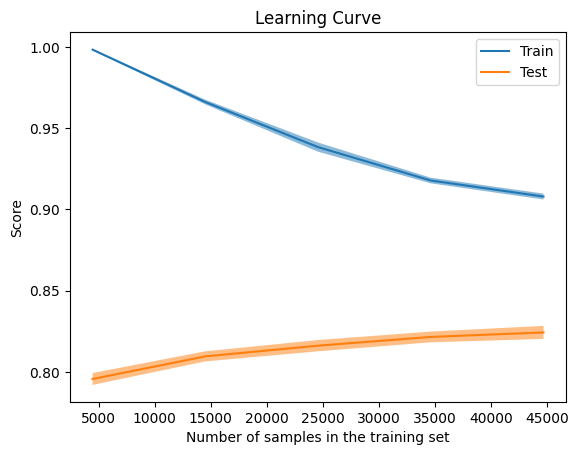

In [118]:
LearningCurveDisplay.from_estimator(
    final_model_tuned,
    x_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=sf,
    random_state=42
)
plt.title("Learning Curve")
plt.show()

## 7.6 Model Explanation and Interpretation

### 7.6.1 Explanation using Feature Importances

In [119]:
# Feature Importances

feature_importances = final_model_tuned.named_steps["classifier"].feature_importances_
feature_names = final_model_tuned.named_steps["preprocessor"].get_feature_names_out()
feature_importances_df = pd.DataFrame(
    {"feature": feature_names, "importance": feature_importances}
).sort_values("importance", ascending=False)

top10 = feature_importances_df.head(10)
top10

,feature,importance
31,deposit_type_Non Refund,0.246388
9,required_car_parking_spaces,0.199524
17,market_segment_Online TA,0.130759
10,total_of_special_requests,0.047679
43,0_7,0.036291
40,0_4,0.032995
34,customer_type_Transient,0.026842
4,previous_cancellations,0.026548
39,0_3,0.022023
41,0_5,0.021217


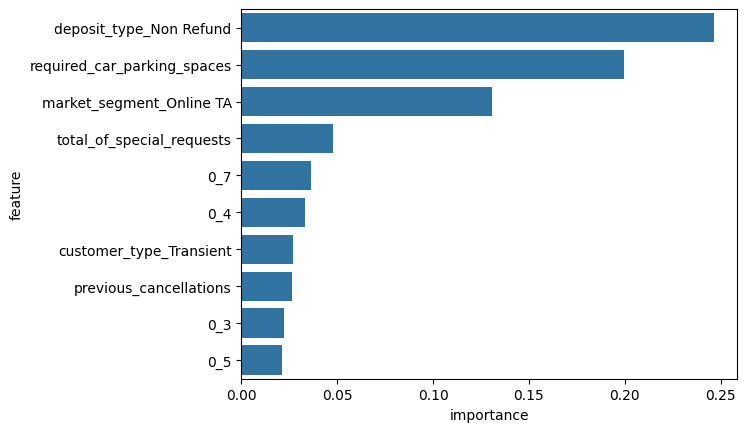

In [120]:
sns.barplot(x="importance", y="feature", data=top10)
plt.show()

### 7.6.2 Explanation using SHAP Values 

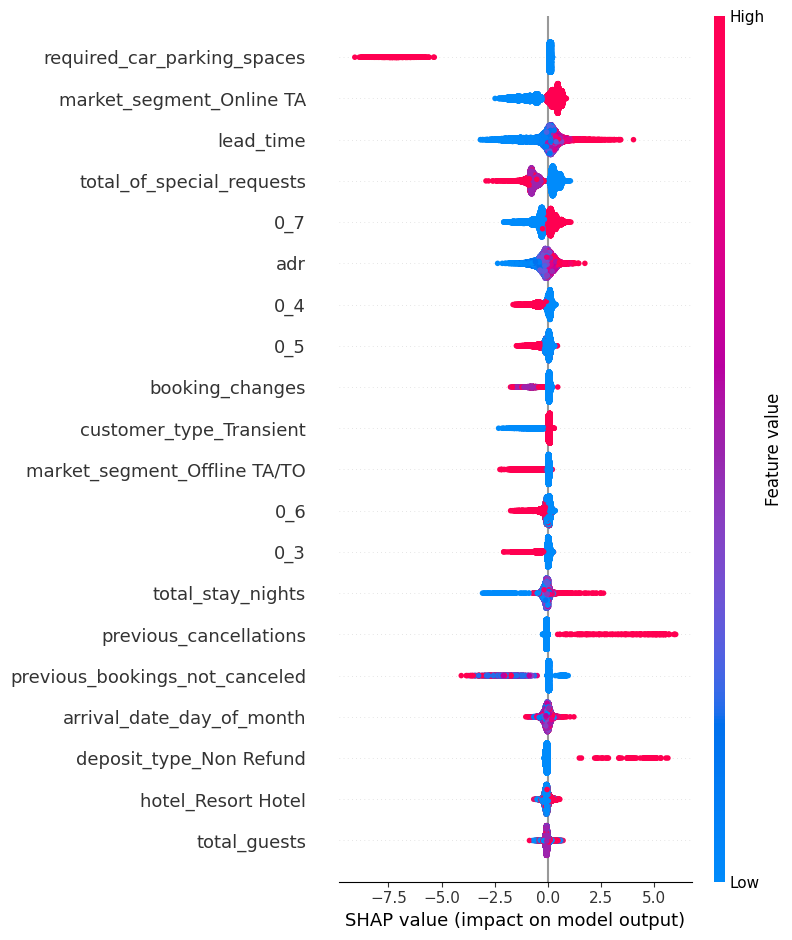

In [121]:
import shap
# Ambil classifier
model = final_model_tuned.named_steps["classifier"]

# Siapkan data test sudah lewat feature_generator + preprocessor
X_test_gen = final_model_tuned.named_steps["feature_generator"].transform(x_test)
X_test_pre = final_model_tuned.named_steps["preprocessor"].transform(X_test_gen)

X_test_pre_df = pd.DataFrame(
    X_test_pre, 
    columns=final_model_tuned.named_steps["preprocessor"].get_feature_names_out()
)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_pre)
shap.summary_plot(shap_values, X_test_pre_df)


### 7.6.3 Explanation using Surrogate Models

In [122]:
surrogate_models = clone(final_model_tuned)
surrogate_models.set_params(classifier = models["Logistic Regression"])

surrogate_models.fit(x_test, pred_test)

,steps,"[('feature_generator', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,combinations,"{'total_guests': ['adults', 'children', ...], 'total_stay_nights': ['stays_in_weekend_nights', 'stays_in_week_nights']}"
,transformers,"[('num_pipeline', ...), ('ohe_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [123]:
logreg_models = surrogate_models.named_steps["classifier"]
feature_names = surrogate_models.named_steps["preprocessor"].get_feature_names_out()

coef = pd.DataFrame(logreg_models.coef_, columns = feature_names, index=["coef"]).T
coef["coef_abs"] = coef["coef"].abs()
coef = coef.sort_values("coef_abs", ascending=False)
top10 = coef.head(10)
top10

,coef,coef_abs
required_car_parking_spaces,-3.538829,3.538829
market_segment_Offline TA/TO,-1.940492,1.940492
distribution_channel_TA/TO,-1.228426,1.228426
previous_cancellations,0.925695,0.925695
market_segment_Online TA,0.903473,0.903473
customer_type_Transient-Party,-0.794103,0.794103
0_4,-0.746385,0.746385
0_3,-0.741841,0.741841
market_segment_Groups,-0.570098,0.570098
adr,0.544012,0.544012


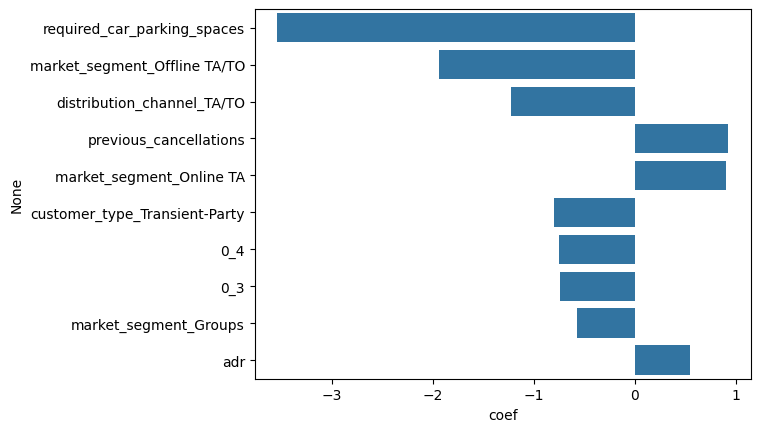

In [124]:
sns.barplot(x="coef", y=top10.index, data=top10)
plt.show()

# Section 8: Model Deployment

---
---
# OUT OF SECTIONS
-- Test Site --

---
---

In [ ]:
# Cek jumlah total duplikat
print("Total duplicate rows:", df.duplicated().sum())

# Ambil semua duplikat
duplicated_rows = df[df.duplicated(keep=False)]

# 1. Distribusi duplikat berdasarkan hotel type
print("\nDuplicate distribution by hotel:")
print(duplicated_rows['hotel'].value_counts(normalize=True) * 100)

# 2. Distribusi duplikat berdasarkan market_segment
print("\nDuplicate distribution by market_segment:")
print(duplicated_rows['market_segment'].value_counts(normalize=True) * 100)

# 3. Distribusi duplikat berdasarkan deposit_type
print("\nDuplicate distribution by deposit_type:")
print(duplicated_rows['deposit_type'].value_counts(normalize=True) * 100)

# 4. Distribusi duplikat berdasarkan lead_time (statistical summary)
print("\nDuplicate distribution - lead_time summary:")
print(duplicated_rows['lead_time'].describe())

# 5. Distribusi duplikat berdasarkan reservation_status
print("\nDuplicate distribution by reservation_status:")
print(duplicated_rows['reservation_status'].value_counts(normalize=True) * 100)


Total duplicate rows: 31994

Duplicate distribution by hotel:
hotel
City Hotel      79.043944
Resort Hotel    20.956056
Name: proportion, dtype: float64

Duplicate distribution by market_segment:
market_segment
Groups           41.610855
Offline TA/TO    30.399602
Online TA        20.587576
Corporate         3.669862
Direct            3.498070
Complementary     0.186730
Aviation          0.047305
Name: proportion, dtype: float64

Duplicate distribution by deposit_type:
deposit_type
No Deposit    64.167808
Non Refund    35.642973
Refundable     0.189219
Name: proportion, dtype: float64

Duplicate distribution - lead_time summary:
count    40165.000000
mean       160.081912
std        126.463447
min          0.000000
25%         56.000000
50%        133.000000
75%        251.000000
max        629.000000
Name: lead_time, dtype: float64

Duplicate distribution by reservation_status:
reservation_status
Canceled     57.714428
Check-Out    41.613345
No-Show       0.672227
Name: proportion, dt

In [ ]:
df[df.duplicated(keep=False)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119372,City Hotel,0,175,2017,August,35,31,1,3,1,0.0,0,BB,NLD,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


In [ ]:
df["adr"].mean()

101.83112153446686

In [ ]:
# Pivot table ADR untuk perbandingan langsung
pivot_adr = pd.pivot_table(
    df,
    values='adr',
    index='reserved_room_type',
    columns='hotel',
    aggfunc='mean'
).round(2)

print(pivot_adr)


hotel               City Hotel  Resort Hotel
reserved_room_type                          
A                        96.25         76.21
B                        90.32        104.67
C                        85.48        161.36
D                       131.46        103.62
E                       156.80        114.49
F                       189.26        132.76
G                       201.80        168.24
H                          NaN        188.22
L                          NaN        124.67
P                         0.00          0.00


In [ ]:
# mencari jumlah cancel dan tidak berdasarkan deposit_type
df.groupby(['deposit_type', 'is_canceled']).size()

deposit_type  is_canceled
No Deposit    0              74947
              1              29694
Non Refund    0                 93
              1              14494
Refundable    0                126
              1                 36
dtype: int64

In [ ]:
df[df['reserved_room_type']=='P']

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
9376,Resort Hotel,1,0,2016,November,48,21,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,386.0,0,Group,0.0,0,0,Canceled,2016-11-21
60651,City Hotel,1,0,2016,November,47,17,4,11,0,0.0,0,SC,NaN,Corporate,Direct,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-11-17
61244,City Hotel,1,0,2016,December,50,6,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-12-06
61245,City Hotel,1,0,2016,December,50,6,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-12-06
61249,City Hotel,1,0,2016,December,50,6,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-12-06
65907,City Hotel,1,0,2017,April,15,10,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65908,City Hotel,1,0,2017,April,15,10,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65909,City Hotel,1,0,2017,April,15,10,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65910,City Hotel,1,0,2017,April,15,10,0,0,0,0.0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
